In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kuldeepjangra/customer-behavior-and-churn-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 69.5M/69.5M [00:02<00:00, 30.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kuldeepjangra/customer-behavior-and-churn-prediction-dataset/versions/2


In [ ]:
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [ ]:
df1 = pd.read_csv(path + "/customer_summary.csv")
df2 = pd.read_csv(path + "/customers.csv")
df3 = pd.read_csv(path + "/engagement.csv")
df4 = pd.read_csv(path + "/orders.csv")
df5 = pd.read_csv(path + "/payments.csv")
df6 = pd.read_csv(path + "/support_tickets.csv")

In [ ]:
df1.head()

,customer_id,total_orders,total_spent,average_order_value,total_returns,return_rate,loyalty_points,last_purchase_days,purchase_frequency,lifetime_value,customer_segment,churn_risk_score,churn
0,1000001,82,145985.42,1780.31,4,0.049,1459,125,5.79,311103.65,Loyal,37.9,No
1,1000002,87,784538.16,9017.68,8,0.092,7845,44,2.43,897900.59,High Value,35.0,No
2,1000003,12,36172.08,3014.34,8,0.667,361,308,4.68,49858.61,At Risk,78.2,Yes
3,1000004,84,719480.16,8565.24,6,0.071,7194,112,3.05,1071641.95,High Value,40.2,No
4,1000005,112,64370.88,574.74,2,0.018,643,357,4.32,95849.52,Loyal,60.5,Yes


In [ ]:
df2.head()

,customer_id,first_name,last_name,age,gender,city,state,country,signup_date,tenure_months,membership_tier,occupation,income_group,marital_status,education,preferred_device,referral_source
0,1000001,Customer,0,23,Male,Mumbai,Haryana,India,2025-06-19,8,Gold,Designer,Low,Single,High School,Android,Social Media
1,1000002,Customer,1,62,Female,Mumbai,West Bengal,India,2020-07-10,52,Platinum,Teacher,Medium,Single,Bachelor,Android,Ads
2,1000003,Customer,2,55,Female,Hyderabad,Telangana,India,2024-11-16,41,Basic,Designer,Medium,Single,Bachelor,Web,Friend
3,1000004,Customer,3,43,Female,Mumbai,Tamil Nadu,India,2018-08-22,47,Basic,Business,Low,Married,Master,iPhone,Organic
4,1000005,Customer,4,43,Male,Bengaluru,Telangana,India,2018-11-29,56,Silver,Teacher,High,Married,Bachelor,Android,Friend


In [ ]:
df3.head()

,customer_id,app_usage_minutes,website_sessions,avg_session_duration,search_frequency,pages_viewed,wishlist_items,cart_abandon_rate,notification_click_rate,email_open_rate,days_since_last_login
0,1000001,62,2,33.9,31,115,8,0.74,0.68,0.89,44
1,1000002,221,3,3.3,27,120,32,0.60,0.56,0.72,359
2,1000003,284,27,11.5,75,143,0,0.76,0.16,0.42,142
3,1000004,84,14,43.2,43,53,5,0.38,0.36,0.34,135
4,1000005,27,47,21.8,15,499,24,0.08,0.29,0.63,185


In [ ]:
df4.head()

,order_id,customer_id,order_date,product_category,product_name,quantity,unit_price,discount_percent,order_amount,payment_method,coupon_used,delivery_days,order_status,returned,return_reason,seller_rating,customer_rating
0,5000001,1335244,2025-02-11,Electronics,Laptop,3,12320.10,5,35112.29,UPI,No,1,Returned,Yes,Damaged,3.1,2
1,5000002,1121982,2023-09-15,Beauty,Perfume,1,28106.13,25,21079.60,Credit Card,No,10,Returned,Yes,NaN,3.6,1
2,5000003,1397834,2022-10-10,Fashion,Shoes,4,17078.50,5,64898.30,UPI,Yes,7,Delivered,No,NaN,3.2,3
3,5000004,1316527,2025-03-11,Grocery,Rice,4,26857.78,15,91316.45,Debit Card,No,10,Delivered,No,NaN,3.4,1
4,5000005,1024026,2023-04-06,Fashion,Jeans,1,42780.35,30,29946.24,Debit Card,No,6,Delivered,No,NaN,3.3,3


In [ ]:
df5.head()

,payment_id,customer_id,payment_method,payment_status,payment_failures,refund_amount,subscription_active,subscription_fee,average_monthly_spend,last_payment_date
0,9000001,1000001,Credit Card,Refunded,0,0.0,Yes,199,14960.23,2026-11-24
1,9000002,1000002,Credit Card,Failed,4,0.0,Yes,999,1119.76,2026-01-18
2,9000003,1000003,UPI,Success,5,0.0,Yes,999,4798.59,2026-07-11
3,9000004,1000004,Debit Card,Success,0,0.0,No,0,3531.85,2026-07-04
4,9000005,1000005,UPI,Refunded,3,0.0,No,0,17026.14,2026-09-04


In [ ]:
df6.head()

,ticket_id,customer_id,tickets_last_year,complaint_category,avg_resolution_hours,satisfaction_score,escalated,issue_status
0,7000001,1335244,1,Account Issue,18.4,1.6,Yes,Resolved
1,7000002,1354786,7,Delivery Delay,3.1,1.9,Yes,Resolved
2,7000003,1294255,7,Refund Request,32.9,2.1,Yes,Resolved
3,7000004,1397834,7,Technical Problem,20.7,1.9,Yes,Closed
4,7000005,1053588,7,Payment Issue,26.5,2.4,Yes,Closed


In [ ]:
dfs = [df1, df2, df3, df4, df5]

MERGED THE WHOLE DATASET INTO ONE

In [ ]:
df_final = reduce(lambda left, right: pd.merge(left, right, on = "customer_id", how = "inner"), dfs)

In [ ]:
df_final.head()

,customer_id,total_orders,total_spent,average_order_value,total_returns,return_rate,loyalty_points,last_purchase_days,purchase_frequency,lifetime_value,...,customer_rating,payment_id,payment_method_y,payment_status,payment_failures,refund_amount,subscription_active,subscription_fee,average_monthly_spend,last_payment_date
0,1000001,82,145985.42,1780.31,4,0.049,1459,125,5.79,311103.65,...,3,9000001,Credit Card,Refunded,0,0.0,Yes,199,14960.23,2026-11-24
1,1000002,87,784538.16,9017.68,8,0.092,7845,44,2.43,897900.59,...,3,9000002,Credit Card,Failed,4,0.0,Yes,999,1119.76,2026-01-18
2,1000003,12,36172.08,3014.34,8,0.667,361,308,4.68,49858.61,...,4,9000003,UPI,Success,5,0.0,Yes,999,4798.59,2026-07-11
3,1000004,84,719480.16,8565.24,6,0.071,7194,112,3.05,1071641.95,...,1,9000004,Debit Card,Success,0,0.0,No,0,3531.85,2026-07-04
4,1000004,84,719480.16,8565.24,6,0.071,7194,112,3.05,1071641.95,...,4,9000004,Debit Card,Success,0,0.0,No,0,3531.85,2026-07-04


In [ ]:
df_final.columns

Index(['customer_id', 'total_orders', 'total_spent', 'average_order_value',
       'total_returns', 'return_rate', 'loyalty_points', 'last_purchase_days',
       'purchase_frequency', 'lifetime_value', 'customer_segment',
       'churn_risk_score', 'churn', 'first_name', 'last_name', 'age', 'gender',
       'city', 'state', 'country', 'signup_date', 'tenure_months',
       'membership_tier', 'occupation', 'income_group', 'marital_status',
       'education', 'preferred_device', 'referral_source', 'app_usage_minutes',
       'website_sessions', 'avg_session_duration', 'search_frequency',
       'pages_viewed', 'wishlist_items', 'cart_abandon_rate',
       'notification_click_rate', 'email_open_rate', 'days_since_last_login',
       'order_id', 'order_date', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_percent', 'order_amount',
       'payment_method_x', 'coupon_used', 'delivery_days', 'order_status',
       'returned', 'return_reason', 'seller_rating', 

In [ ]:
df_final.shape

(1000000, 64)

In [ ]:
df_final.describe()

,customer_id,total_orders,total_spent,average_order_value,total_returns,return_rate,loyalty_points,last_purchase_days,purchase_frequency,lifetime_value,...,discount_percent,order_amount,delivery_days,seller_rating,customer_rating,payment_id,payment_failures,refund_amount,subscription_fee,average_monthly_spend
count,1.000000e+06,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.00000
mean,1.249963e+06,60.469844,3.775481e+05,6245.939843,4.805242,0.143280,3774.980375,182.538850,4.193459,6.793144e+05,...,15.010515,63784.201385,5.499761,4.000425,2.998915,9.249963e+06,2.501196,201.267856,249.592189,10246.98904
std,1.442347e+05,34.661114,3.169190e+05,3319.331630,3.173136,0.191554,3169.189033,105.503011,7.947346,6.042568e+05,...,9.990361,51425.319751,2.875322,0.578797,1.413758,1.442347e+05,1.708224,794.202392,331.333555,5632.44479
min,1.000001e+06,1.000000,5.022700e+02,500.120000,0.000000,0.000000,5.000000,0.000000,0.020000,5.883000e+02,...,0.000000,70.320000,1.000000,3.000000,1.000000,9.000001e+06,0.000000,0.000000,0.000000,500.01000
25%,1.125147e+06,31.000000,1.169876e+05,3369.470000,2.000000,0.035000,1169.000000,91.000000,1.000000,2.016689e+05,...,5.000000,23048.150000,3.000000,3.500000,2.000000,9.125147e+06,1.000000,0.000000,0.000000,5362.75000
50%,1.249963e+06,60.000000,2.888344e+05,6246.250000,5.000000,0.081000,2888.000000,183.000000,1.990000,5.018991e+05,...,15.000000,49083.115000,5.000000,4.000000,3.000000,9.249963e+06,3.000000,0.000000,199.000000,10239.23000
75%,1.374689e+06,90.000000,5.697568e+05,9116.520000,8.000000,0.158000,5697.000000,274.000000,3.860000,9.984974e+05,...,25.000000,94085.367500,8.000000,4.500000,4.000000,9.374689e+06,4.000000,0.000000,499.000000,15134.89750
max,1.499998e+06,120.000000,1.438925e+06,11999.990000,10.000000,1.000000,14389.000000,365.000000,116.750000,3.534404e+06,...,30.000000,249976.650000,10.000000,5.000000,5.000000,9.499998e+06,5.000000,4999.900000,999.000000,19999.99000


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 64 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   customer_id              1000000 non-null  int64  
 1   total_orders             1000000 non-null  int64  
 2   total_spent              1000000 non-null  float64
 3   average_order_value      1000000 non-null  float64
 4   total_returns            1000000 non-null  int64  
 5   return_rate              1000000 non-null  float64
 6   loyalty_points           1000000 non-null  int64  
 7   last_purchase_days       1000000 non-null  int64  
 8   purchase_frequency       1000000 non-null  float64
 9   lifetime_value           1000000 non-null  float64
 10  customer_segment         1000000 non-null  object 
 11  churn_risk_score         1000000 non-null  float64
 12  churn                    1000000 non-null  object 
 13  first_name               1000000 non-null  

FIXED THE "returned" COLUMN

In [ ]:
df_final.loc[(df_final["returned"] == "Yes") & (df_final["return_reason"].isna()), "return_reason"] = "Not mentioned"
df_final.loc[(df_final["returned"] == "No") & (df_final["return_reason"].isna()), "return_reason"] = "Not applicable"

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 64 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   customer_id              1000000 non-null  int64  
 1   total_orders             1000000 non-null  int64  
 2   total_spent              1000000 non-null  float64
 3   average_order_value      1000000 non-null  float64
 4   total_returns            1000000 non-null  int64  
 5   return_rate              1000000 non-null  float64
 6   loyalty_points           1000000 non-null  int64  
 7   last_purchase_days       1000000 non-null  int64  
 8   purchase_frequency       1000000 non-null  float64
 9   lifetime_value           1000000 non-null  float64
 10  customer_segment         1000000 non-null  object 
 11  churn_risk_score         1000000 non-null  float64
 12  churn                    1000000 non-null  object 
 13  first_name               1000000 non-null  

In [ ]:
cols_to_drop = ["customer_id", "first_name", "last_name", "order_id", "payment_id", "signup_date", "order_date", "last_payment_date"]

In [ ]:
df_final.drop(cols_to_drop, axis = 1, inplace = True)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 56 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   total_orders             1000000 non-null  int64  
 1   total_spent              1000000 non-null  float64
 2   average_order_value      1000000 non-null  float64
 3   total_returns            1000000 non-null  int64  
 4   return_rate              1000000 non-null  float64
 5   loyalty_points           1000000 non-null  int64  
 6   last_purchase_days       1000000 non-null  int64  
 7   purchase_frequency       1000000 non-null  float64
 8   lifetime_value           1000000 non-null  float64
 9   customer_segment         1000000 non-null  object 
 10  churn_risk_score         1000000 non-null  float64
 11  churn                    1000000 non-null  object 
 12  age                      1000000 non-null  int64  
 13  gender                   1000000 non-null  

In [ ]:
categorical_columns = df_final.select_dtypes(include='object').columns
print(categorical_columns)

Index(['customer_segment', 'churn', 'gender', 'city', 'state', 'country',
       'membership_tier', 'occupation', 'income_group', 'marital_status',
       'education', 'preferred_device', 'referral_source', 'product_category',
       'product_name', 'payment_method_x', 'coupon_used', 'order_status',
       'returned', 'return_reason', 'payment_method_y', 'payment_status',
       'subscription_active'],
      dtype='object')


In [ ]:
df_final["churn_risk_score"]

,churn_risk_score
0,37.9
1,35.0
2,78.2
3,40.2
4,40.2
...,...
999995,62.9
999996,62.9
999997,62.9
999998,55.7


In [ ]:
df_final["churn"]

,churn
0,No
1,No
2,Yes
3,No
4,No
...,...
999995,Yes
999996,Yes
999997,Yes
999998,No


/tmp/ipykernel_2088/4099501606.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='customer_segment', palette='viridis')


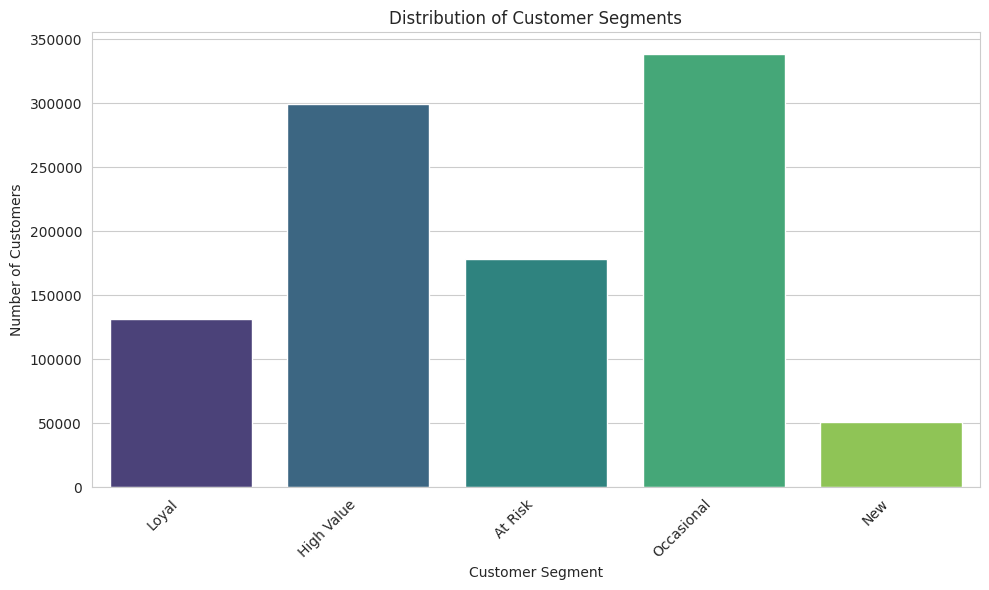

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='customer_segment', palette='viridis')
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2088/3499750000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='churn', palette='viridis')


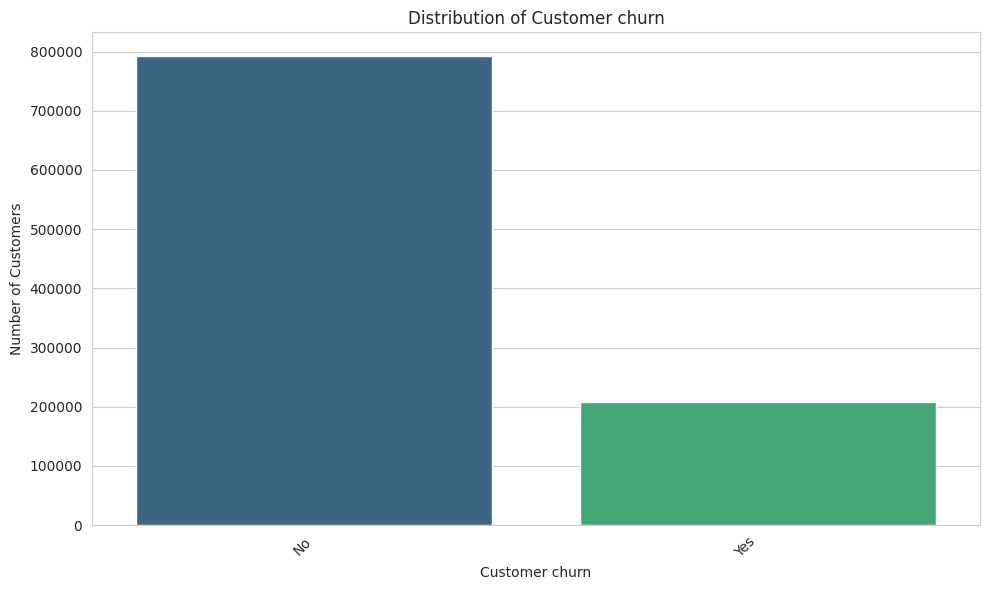

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='churn', palette='viridis')
plt.title('Distribution of Customer churn')
plt.xlabel('Customer churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

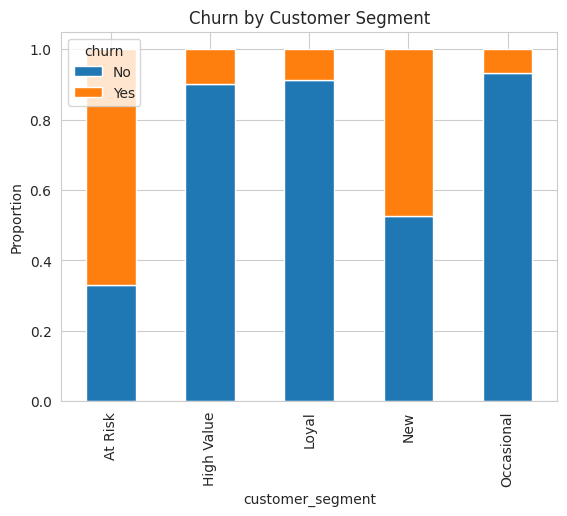

In [ ]:
pd.crosstab(
    df_final["customer_segment"],
    df_final["churn"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.ylabel("Proportion")
plt.title("Churn by Customer Segment")
plt.show()

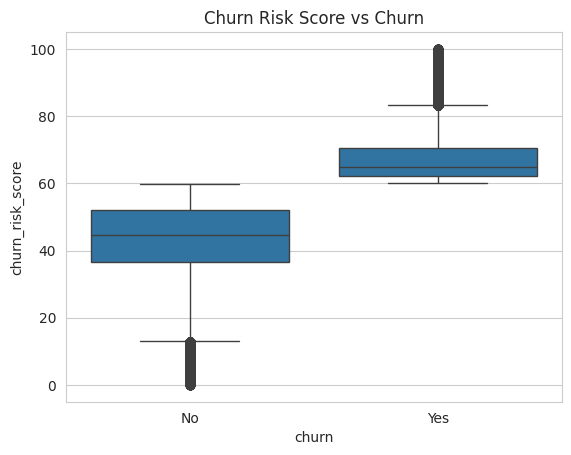

In [ ]:
sns.boxplot(
    data=df_final,
    x="churn",
    y="churn_risk_score"
)

plt.title("Churn Risk Score vs Churn")
plt.show()

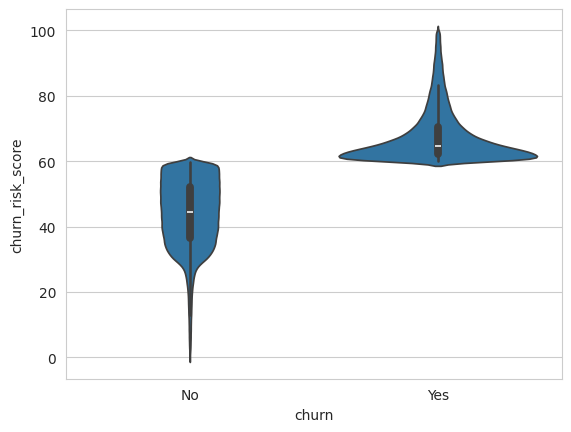

In [ ]:
sns.violinplot(
    data=df_final,
    x="churn",
    y="churn_risk_score"
)

plt.show()

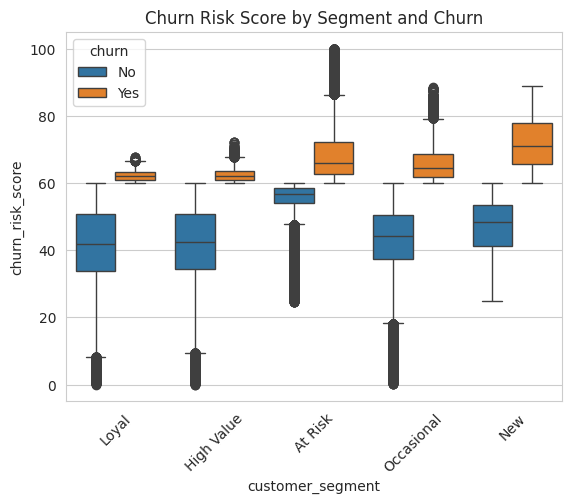

In [ ]:
sns.boxplot(
    data=df_final,
    x="customer_segment",
    y="churn_risk_score",
    hue="churn"
)

plt.xticks(rotation=45)
plt.title("Churn Risk Score by Segment and Churn")
plt.show()

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [ ]:
print("Shape of dataset:", df_final.shape)

print("\nDataset Info:")
df_final.info()

Shape of dataset: (1000000, 56)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 56 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   total_orders             1000000 non-null  int64  
 1   total_spent              1000000 non-null  float64
 2   average_order_value      1000000 non-null  float64
 3   total_returns            1000000 non-null  int64  
 4   return_rate              1000000 non-null  float64
 5   loyalty_points           1000000 non-null  int64  
 6   last_purchase_days       1000000 non-null  int64  
 7   purchase_frequency       1000000 non-null  float64
 8   lifetime_value           1000000 non-null  float64
 9   customer_segment         1000000 non-null  object 
 10  churn_risk_score         1000000 non-null  float64
 11  churn                    1000000 non-null  object 
 12  age                      1000000 non-null  int64  
 

In [ ]:
missing = df_final.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [ ]:
missing_pct = (
    df_final.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct[missing_pct > 0]

,0


In [ ]:
duplicate_count = df_final.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
unique_counts = (
    df_final.nunique()
    .sort_values(ascending=False)
)

print(unique_counts)

order_amount               962528
unit_price                 906357
lifetime_value             431939
total_spent                428959
average_monthly_spend      387828
average_order_value        360632
refund_amount               33542
loyalty_points              14019
purchase_frequency           6945
churn_risk_score             1001
pages_viewed                  500
avg_session_duration          431
last_purchase_days            366
days_since_last_login         366
return_rate                   305
app_usage_minutes             296
search_frequency              121
tenure_months                 120
total_orders                  120
notification_click_rate       101
email_open_rate               101
cart_abandon_rate             101
website_sessions               60
age                            58
wishlist_items                 51
seller_rating                  21
product_name                   15
total_returns                  11
delivery_days                  10
occupation    

In [ ]:
numeric_cols = df_final.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = df_final.select_dtypes(
    include=["object"]
).columns

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nNumerical columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Number of numerical columns: 33
Number of categorical columns: 23

Numerical columns:
['total_orders', 'total_spent', 'average_order_value', 'total_returns', 'return_rate', 'loyalty_points', 'last_purchase_days', 'purchase_frequency', 'lifetime_value', 'churn_risk_score', 'age', 'tenure_months', 'app_usage_minutes', 'website_sessions', 'avg_session_duration', 'search_frequency', 'pages_viewed', 'wishlist_items', 'cart_abandon_rate', 'notification_click_rate', 'email_open_rate', 'days_since_last_login', 'quantity', 'unit_price', 'discount_percent', 'order_amount', 'delivery_days', 'seller_rating', 'customer_rating', 'payment_failures', 'refund_amount', 'subscription_fee', 'average_monthly_spend']

Categorical columns:
['customer_segment', 'churn', 'gender', 'city', 'state', 'country', 'membership_tier', 'occupation', 'income_group', 'marital_status', 'education', 'preferred_device', 'referral_source', 'product_category', 'product_name', 'payment_method_x', 'coupon_used', 'order_status',

In [ ]:
df_final[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,1000000.0,60.469844,34.661114,1.00,31.0000,60.000,90.0000,120.00
total_spent,1000000.0,377548.074012,316918.998074,502.27,116987.5600,288834.420,569756.8200,1438924.80
average_order_value,1000000.0,6245.939843,3319.331630,500.12,3369.4700,6246.250,9116.5200,11999.99
total_returns,1000000.0,4.805242,3.173136,0.00,2.0000,5.000,8.0000,10.00
return_rate,1000000.0,0.143280,0.191554,0.00,0.0350,0.081,0.1580,1.00
loyalty_points,1000000.0,3774.980375,3169.189033,5.00,1169.0000,2888.000,5697.0000,14389.00
last_purchase_days,1000000.0,182.538850,105.503011,0.00,91.0000,183.000,274.0000,365.00
purchase_frequency,1000000.0,4.193459,7.947346,0.02,1.0000,1.990,3.8600,116.75
lifetime_value,1000000.0,679314.367617,604256.803641,588.30,201668.9400,501899.105,998497.3800,3534404.35
churn_risk_score,1000000.0,48.690385,13.980991,0.00,38.6000,48.600,58.2000,100.00


In [ ]:
for col in categorical_cols:
    print("\n" + "=" * 50)
    print(col)
    print("=" * 50)
    print(df_final[col].value_counts(dropna=False).head(20))


customer_segment
customer_segment
Occasional    338556
High Value    299572
At Risk       178566
Loyal         131827
New            51479
Name: count, dtype: int64

churn
churn
No     792787
Yes    207213
Name: count, dtype: int64

gender
gender
Male      491421
Female    488753
Other      19826
Name: count, dtype: int64

city
city
Ahmedabad    125781
Chennai      125756
Faridabad    125181
Hyderabad    125009
Mumbai       125008
Delhi        124795
Bengaluru    124315
Kolkata      124155
Name: count, dtype: int64

state
state
Tamil Nadu     126151
Telangana      125496
Karnataka      125417
West Bengal    124950
Haryana        124937
Maharashtra    124665
Gujarat        124527
Delhi          123857
Name: count, dtype: int64

country
country
India    1000000
Name: count, dtype: int64

membership_tier
membership_tier
Basic       549732
Silver      249717
Gold        150865
Platinum     49686
Name: count, dtype: int64

occupation
occupation
Designer    125948
Business    125607
Enginee

In [ ]:
print(df_final["churn"].value_counts())

churn
No     792787
Yes    207213
Name: count, dtype: int64


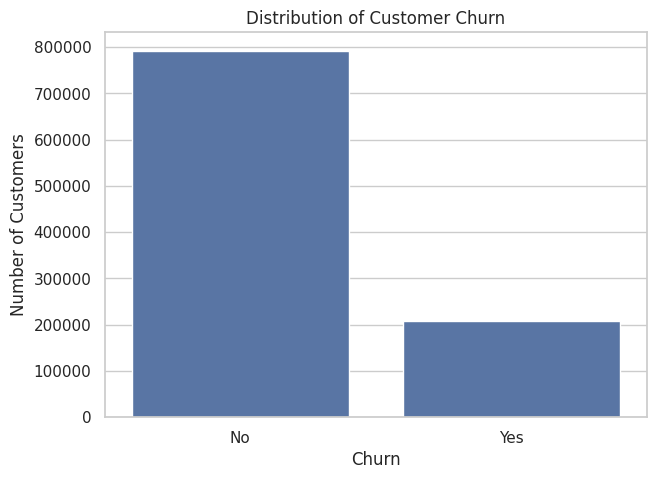

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_final,
    x="churn"
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("/content/drive/MyDrive/Plots/Distribution of Customer Churn.png", dpi=300, bbox_inches="tight")
plt.show()

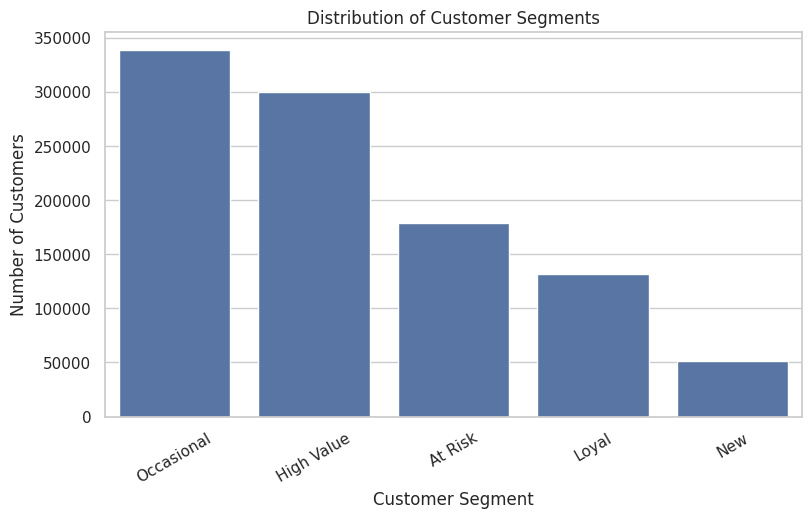

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_final,
    x="customer_segment",
    order=df_final["customer_segment"].value_counts().index
)

plt.title("Distribution of Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.savefig("/content/drive/MyDrive/Plots/Distribution of Customer Segments.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
segment_churn = pd.crosstab(
    df_final["customer_segment"],
    df_final["churn"],
    normalize="index"
) * 100

print(segment_churn)

churn                    No        Yes
customer_segment                      
At Risk           33.046045  66.953955
High Value        90.167973   9.832027
Loyal             91.387197   8.612803
New               52.563181  47.436819
Occasional        93.375394   6.624606


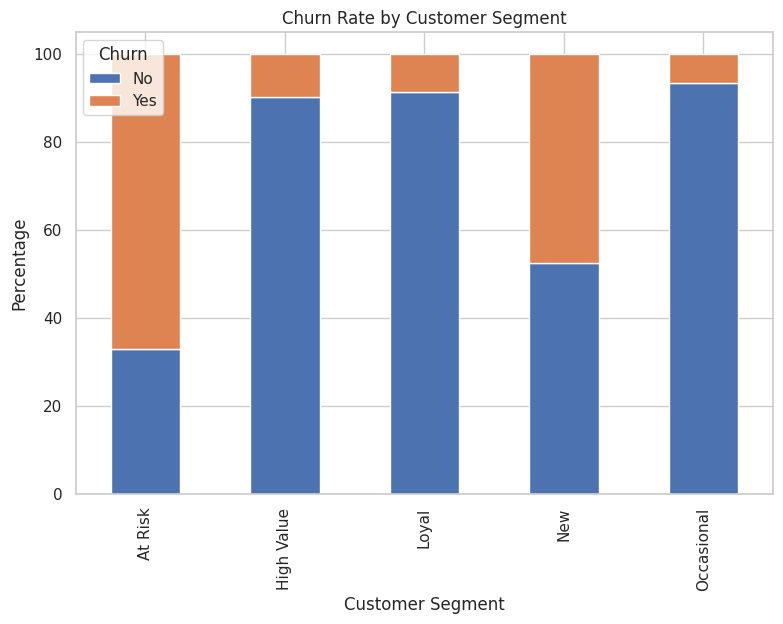

In [ ]:
segment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage")
plt.legend(title="Churn")

plt.savefig("/content/drive/MyDrive/Plots/Churn Rate by Customer Segment.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
churn_rate_segment = (
    df_final
    .assign(churn_binary=df_final["churn"].eq("Yes"))
    .groupby("customer_segment")["churn_binary"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(churn_rate_segment)

customer_segment
At Risk       66.953955
New           47.436819
High Value     9.832027
Loyal          8.612803
Occasional     6.624606
Name: churn_binary, dtype: float64


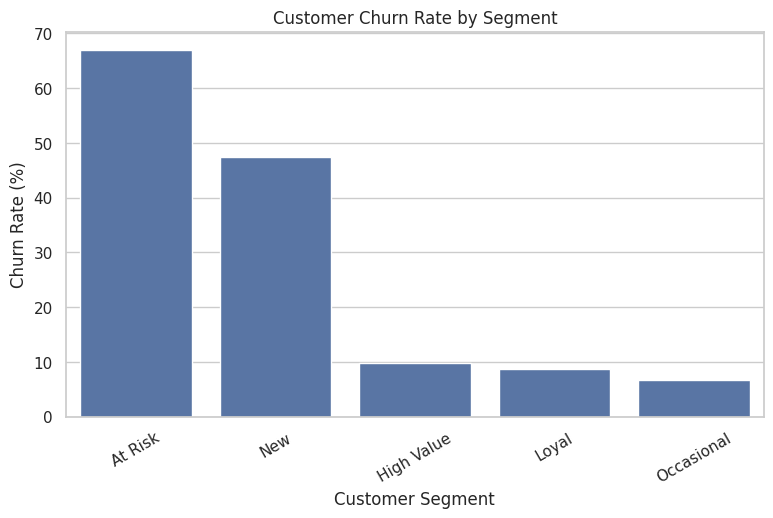

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=churn_rate_segment.index,
    y=churn_rate_segment.values
)

plt.title("Customer Churn Rate by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

plt.savefig("/content/drive/MyDrive/Plots/Customer Churn Rate by Segment.png", dpi=300, bbox_inches="tight")
plt.show()

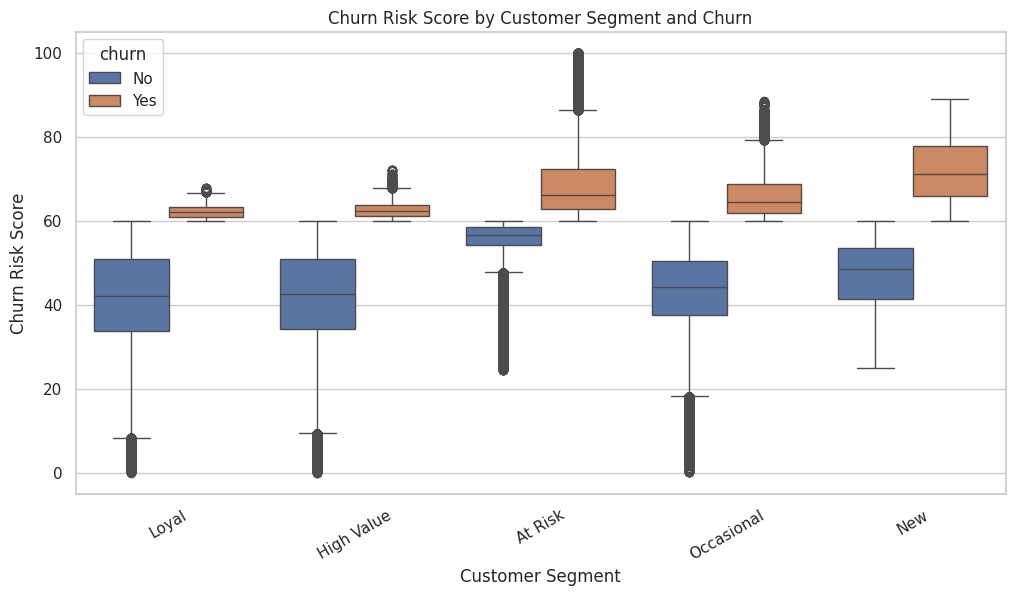

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_final,
    x="customer_segment",
    y="churn_risk_score",
    hue="churn"
)

plt.title("Churn Risk Score by Customer Segment and Churn")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Risk Score")

plt.xticks(rotation=30)

plt.savefig("/content/drive/MyDrive/Plots/Churn Risk Score by Customer Segment and Churn.png", dpi=300, bbox_inches="tight")
plt.show()

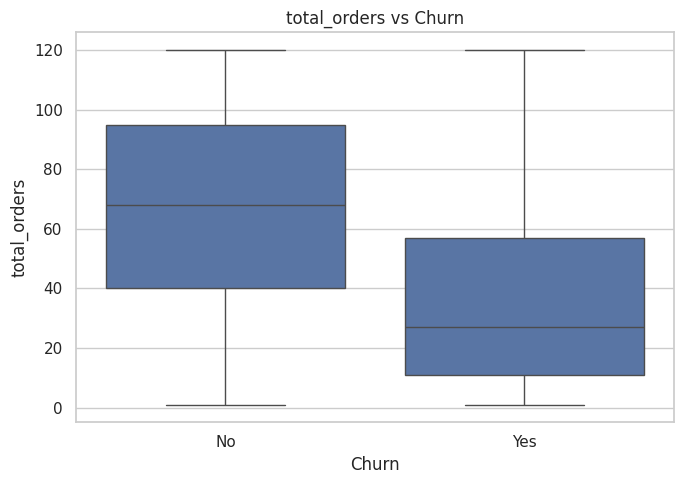

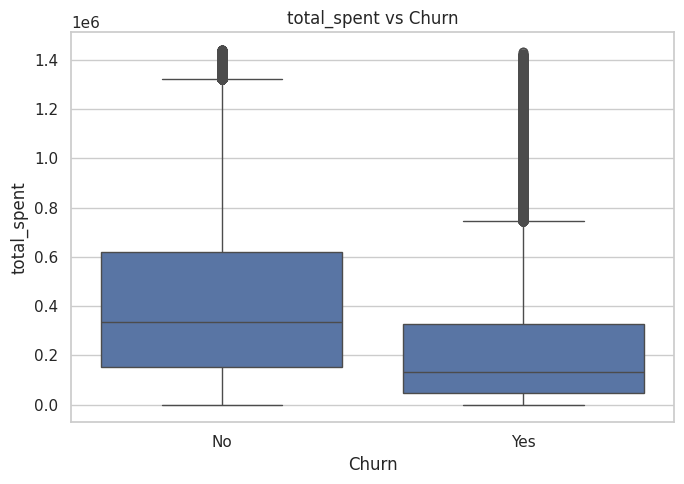

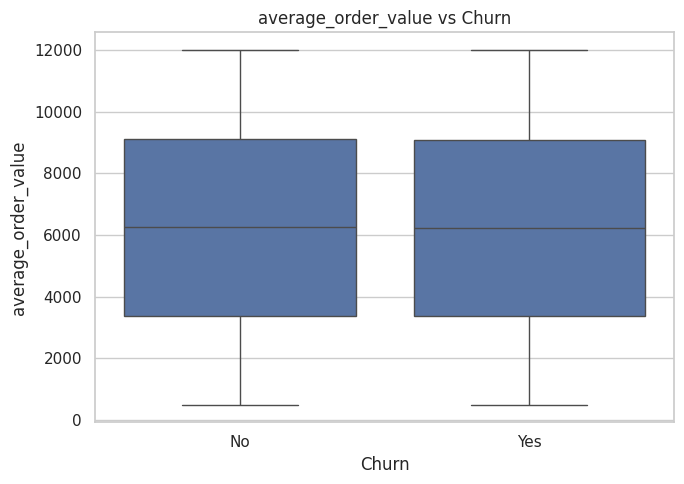

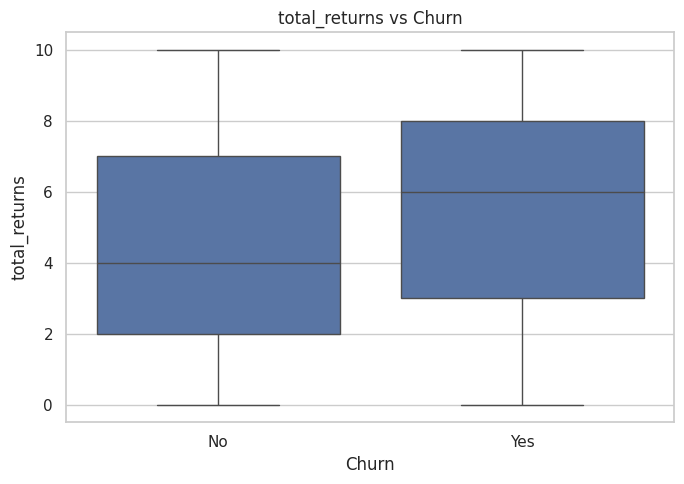

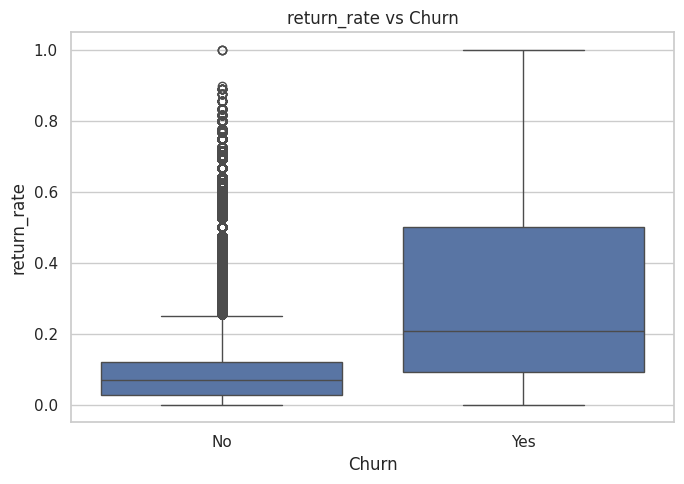

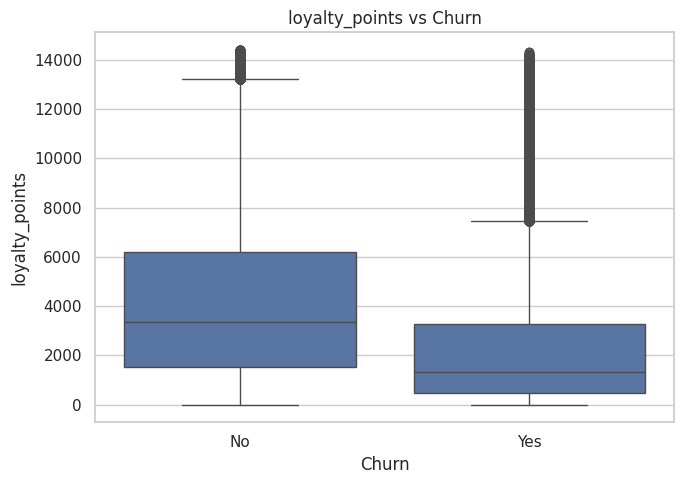

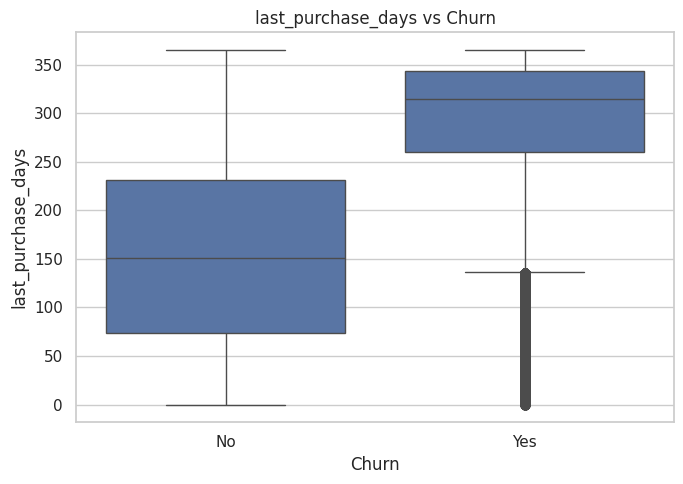

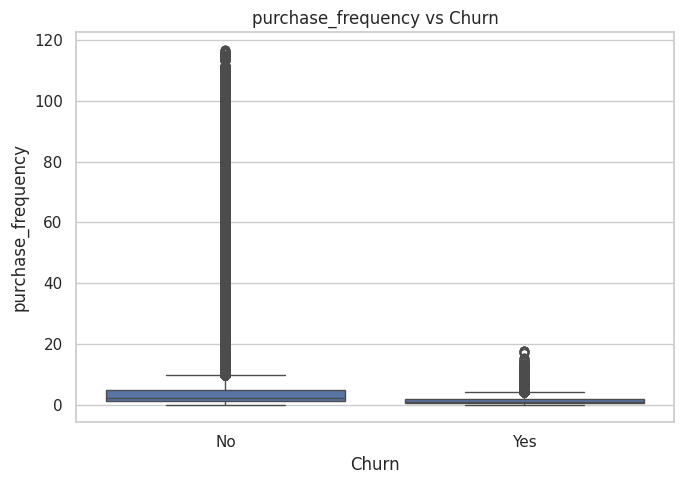

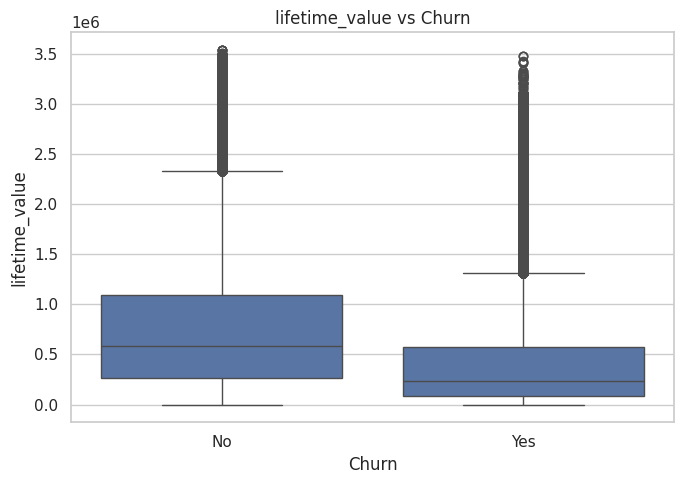

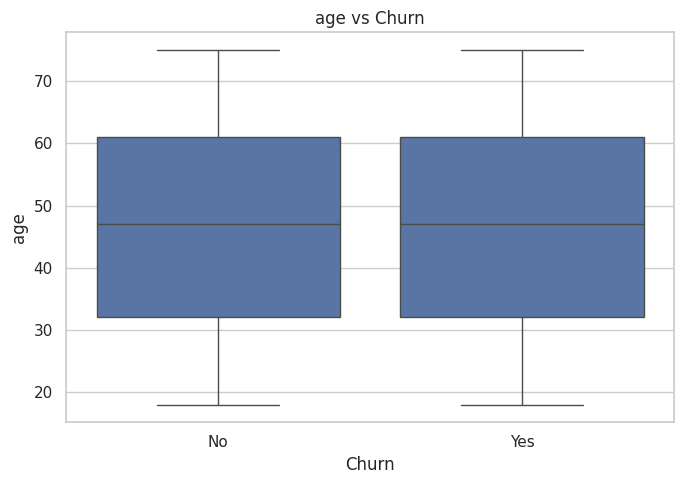

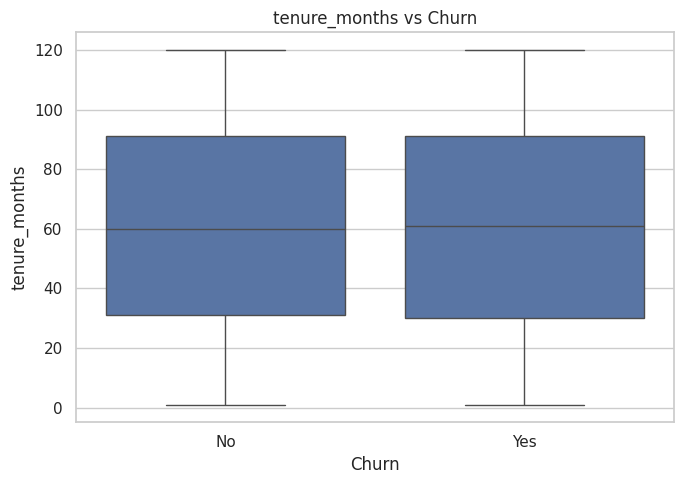

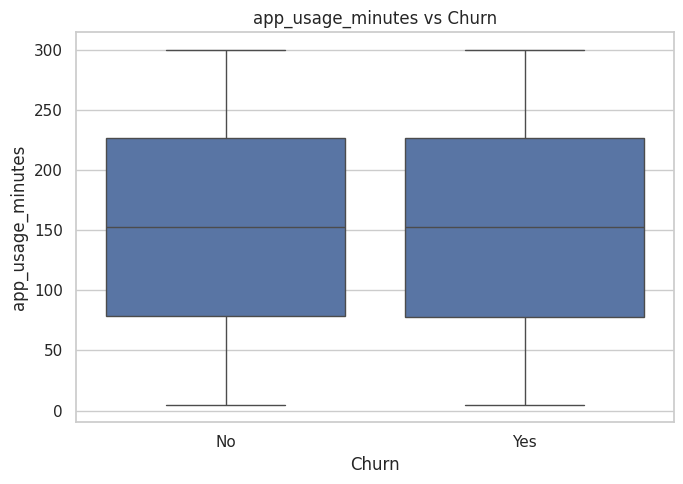

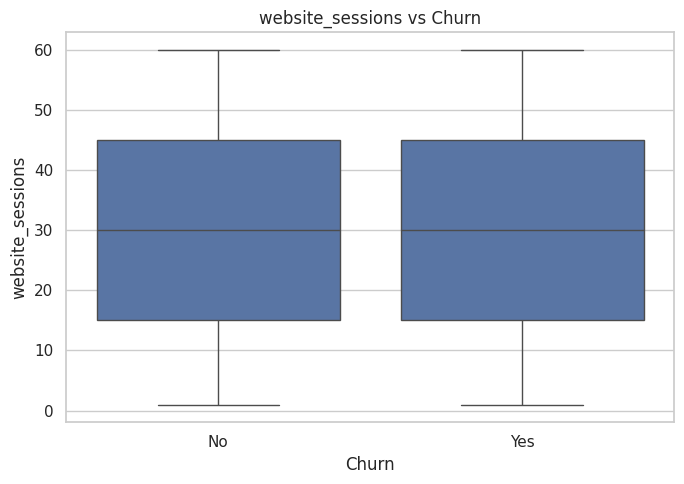

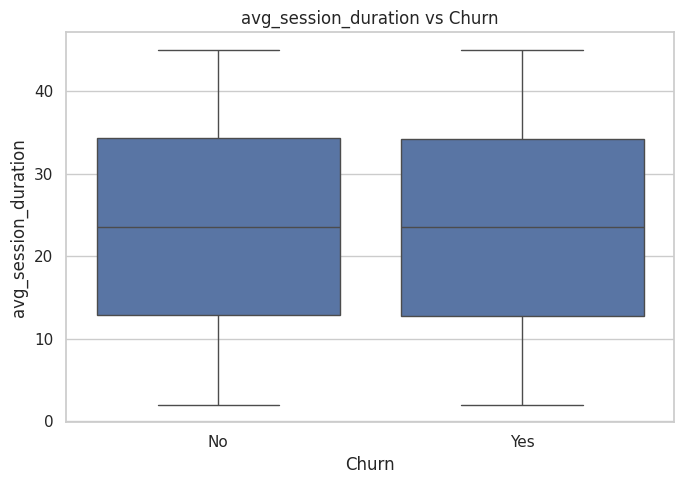

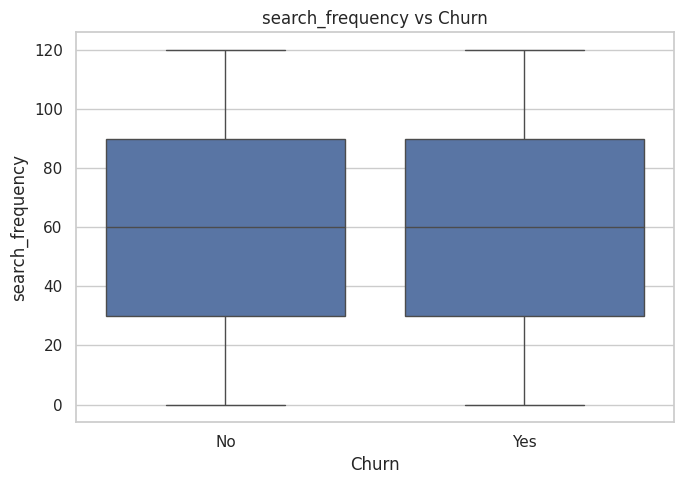

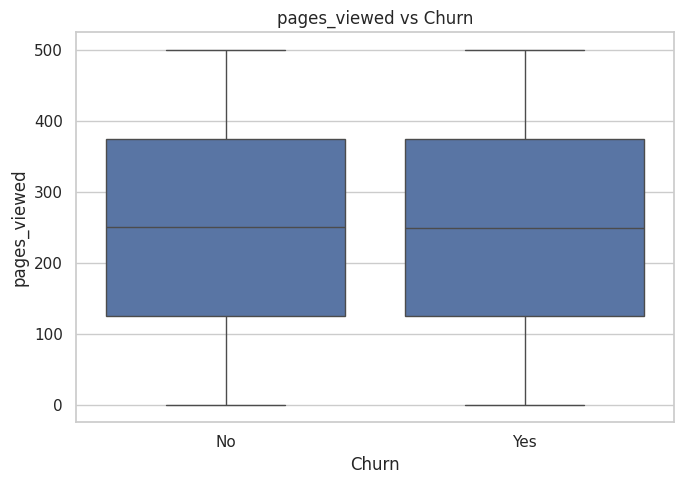

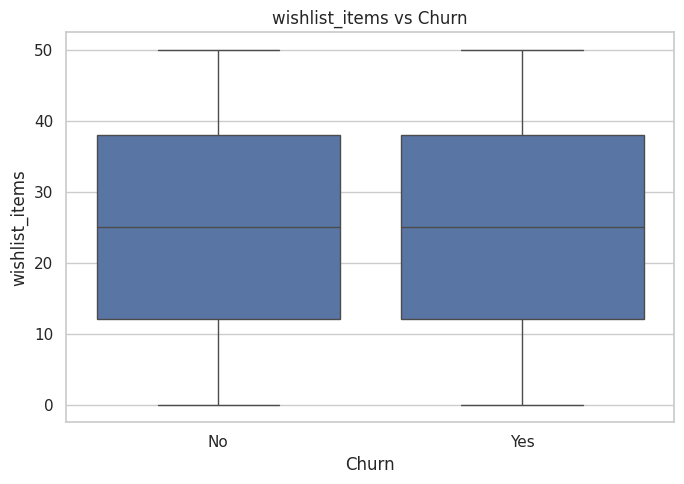

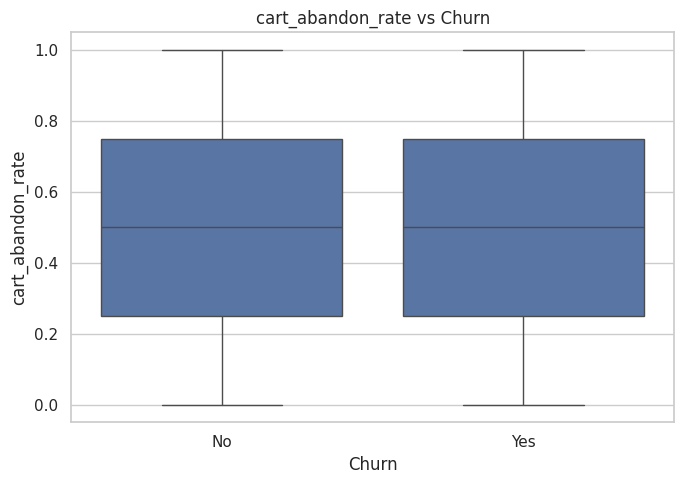

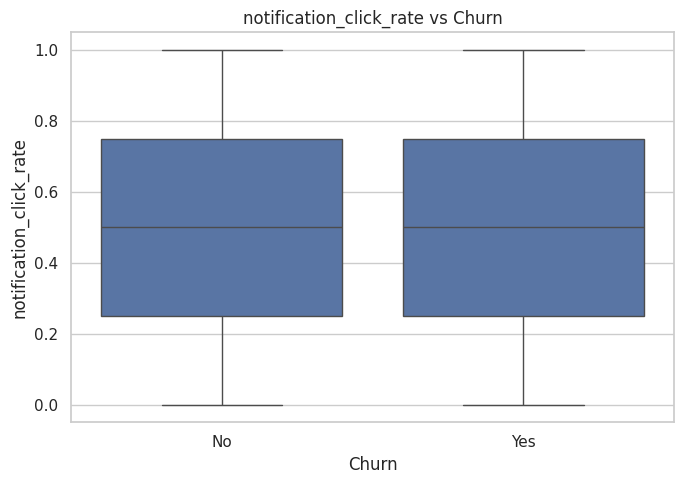

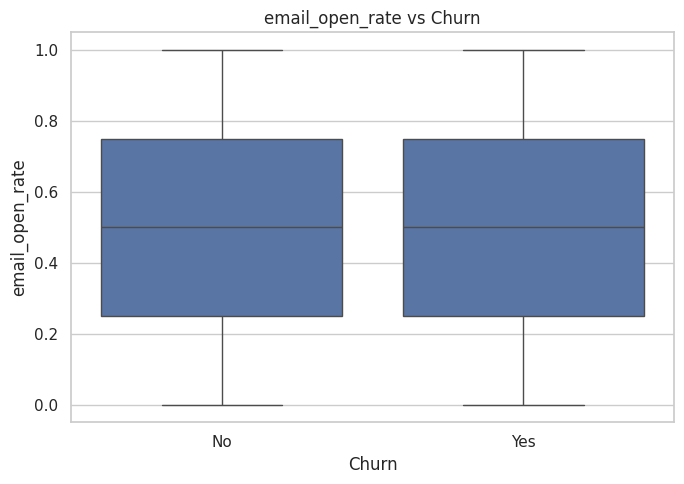

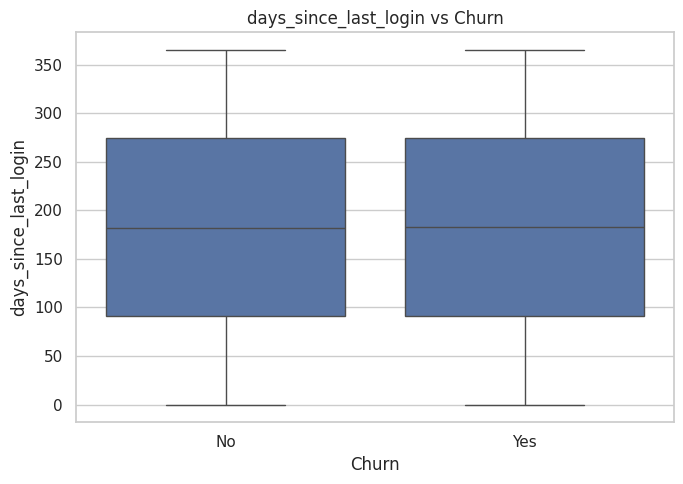

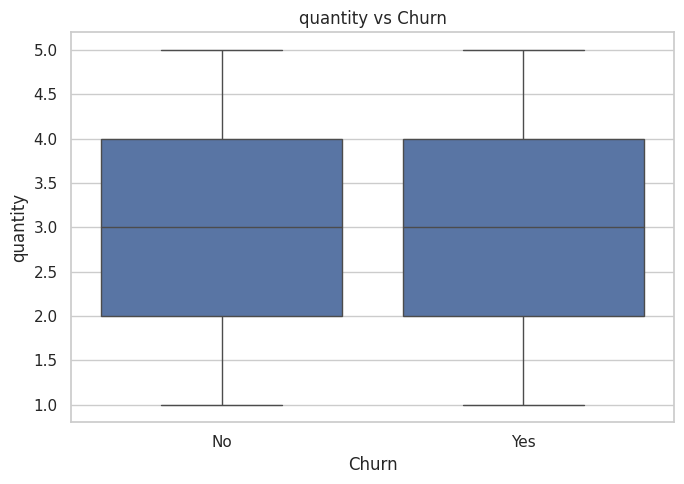

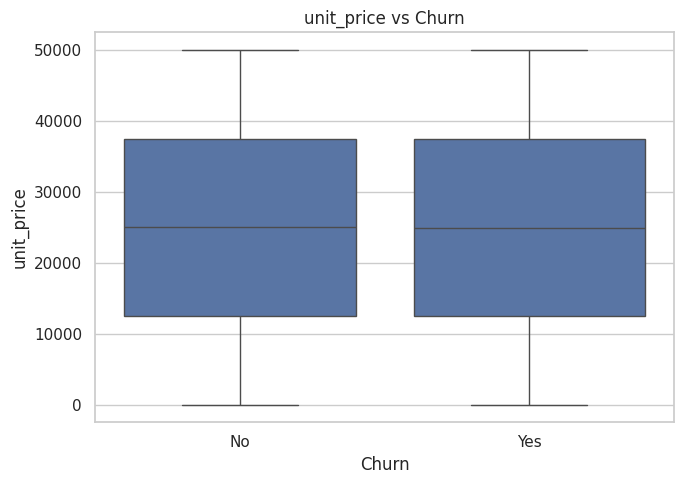

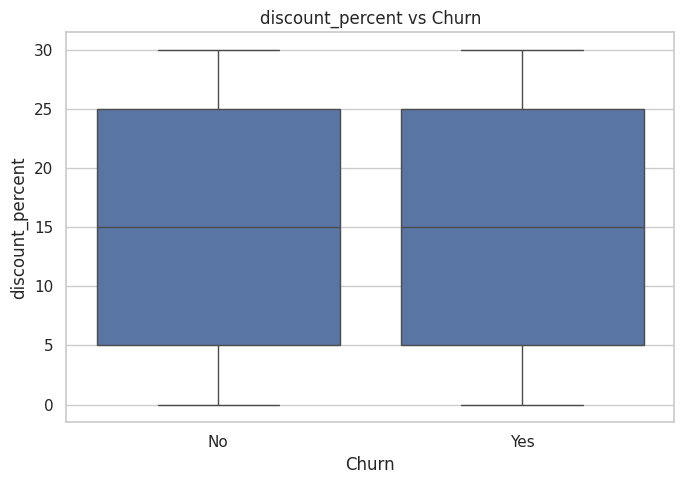

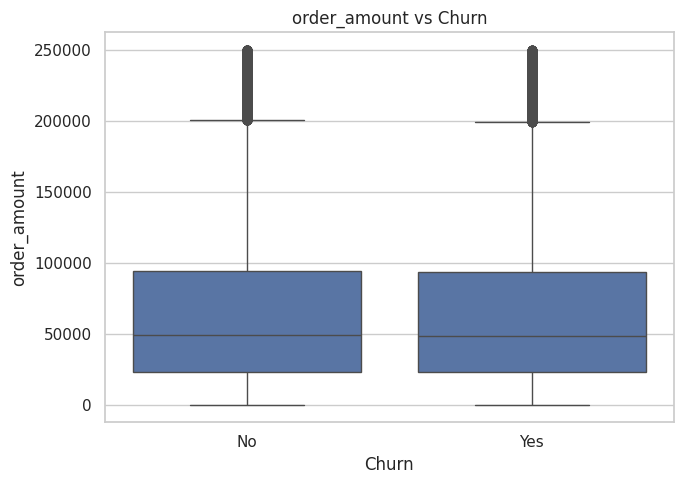

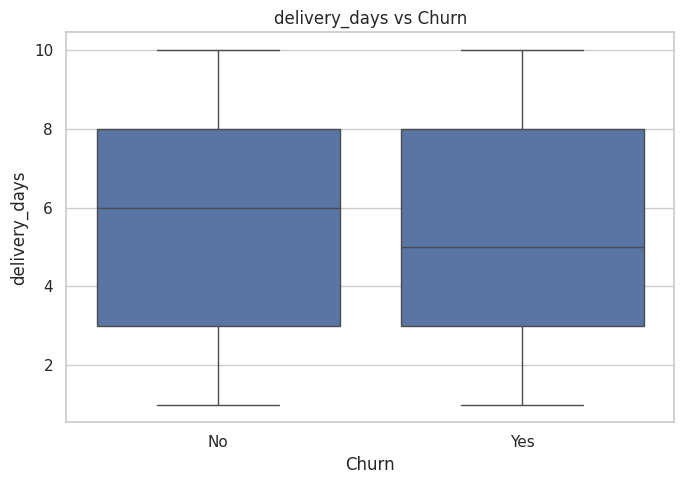

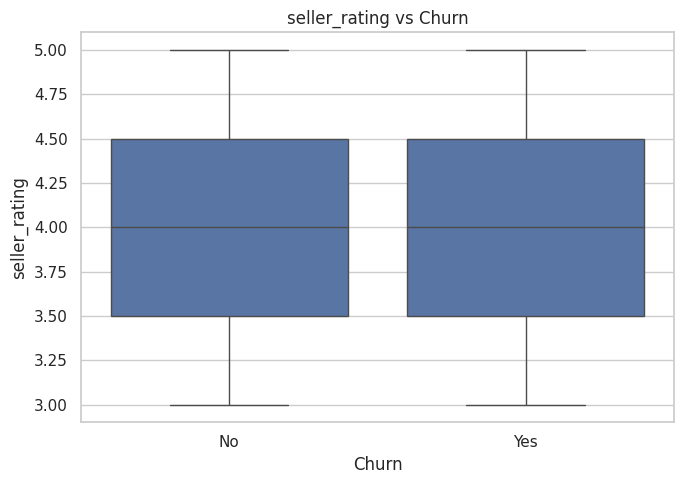

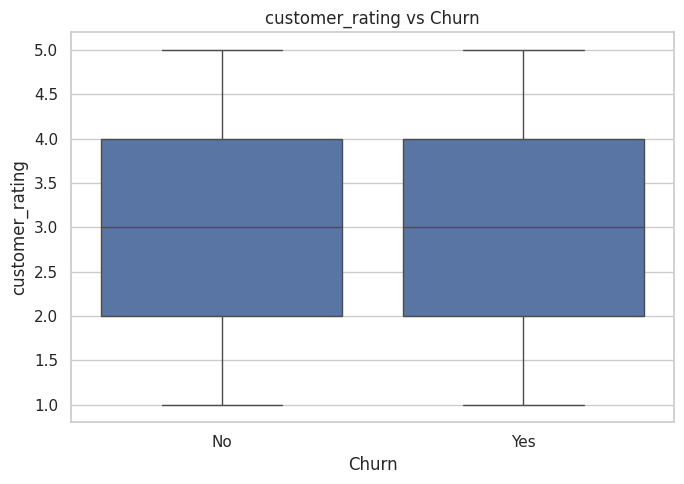

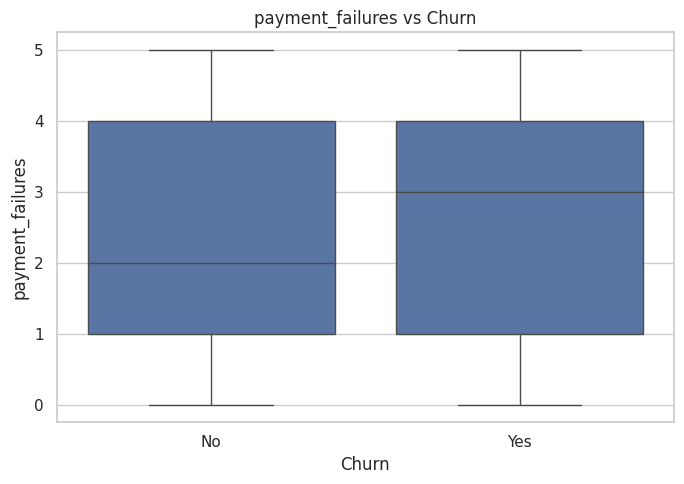

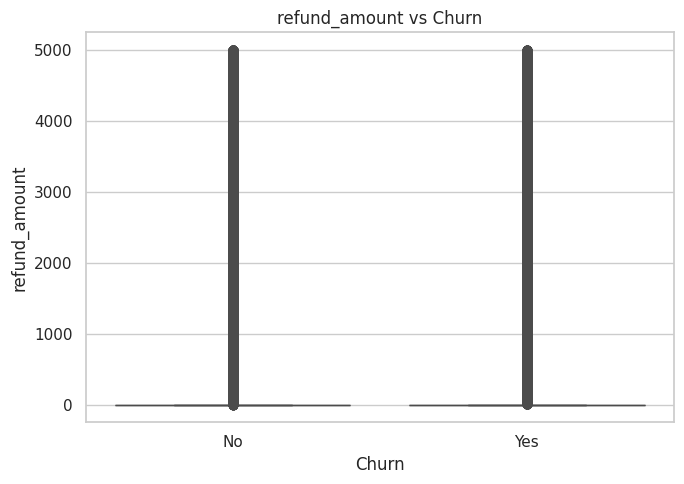

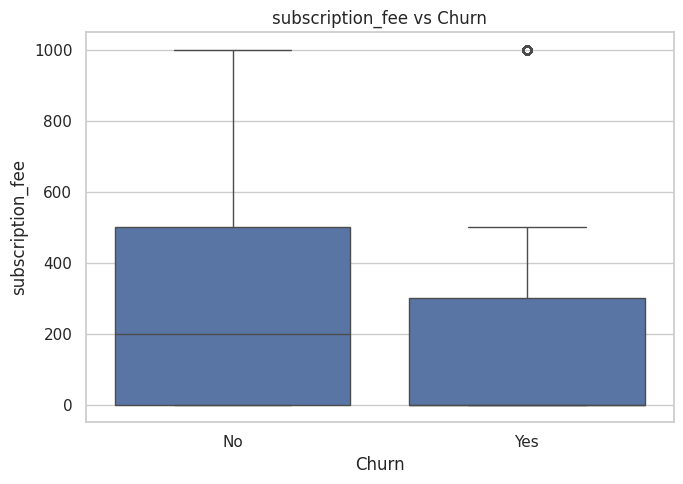

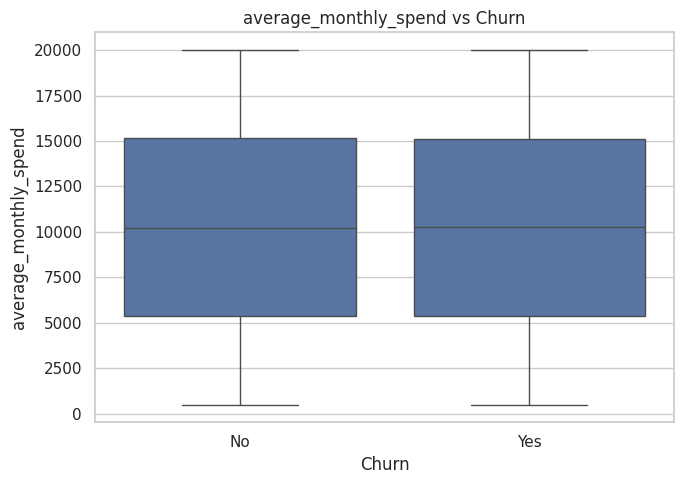

In [ ]:
for col in numeric_cols:

    if col == "churn_risk_score":
        continue

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df_final,
        x="churn",
        y=col
    )

    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)

    plt.tight_layout()
    plt.savefig(
        f"{col}_vs_churn.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [ ]:
numeric_churn_summary = (
    df_final
    .groupby("churn")[numeric_cols]
    .mean()
    .T
)

print(numeric_churn_summary)

churn                               No            Yes
total_orders                 66.566450      37.144523
total_spent              415708.701888  231547.341950
average_order_value        6248.712990    6235.329916
total_returns                 4.600789       5.587468
return_rate                   0.094789       0.328803
loyalty_points             4156.586519    2314.973568
last_purchase_days          154.952900     288.081370
purchase_frequency            4.940973       1.333508
lifetime_value           748201.832248  415754.231805
churn_risk_score             43.695902      67.799034
age                          46.488798      46.564776
tenure_months                60.525268      60.717122
app_usage_minutes           152.617014     152.934956
website_sessions             30.437624      30.374692
avg_session_duration         23.488552      23.468321
search_frequency             59.896163      59.806499
pages_viewed                250.513496     250.459913
wishlist_items              

In [ ]:
numeric_churn_summary["difference"] = (
    numeric_churn_summary["Yes"]
    - numeric_churn_summary["No"]
)

numeric_churn_summary.sort_values(
    "difference",
    ascending=False
)

churn,No,Yes,difference
last_purchase_days,154.952900,288.081370,133.128470
churn_risk_score,43.695902,67.799034,24.103132
average_monthly_spend,10246.311344,10249.581872,3.270528
total_returns,4.600789,5.587468,0.986679
days_since_last_login,182.220396,182.919185,0.698789
app_usage_minutes,152.617014,152.934956,0.317941
return_rate,0.094789,0.328803,0.234014
tenure_months,60.525268,60.717122,0.191854
age,46.488798,46.564776,0.075978
payment_failures,2.500363,2.504384,0.004022


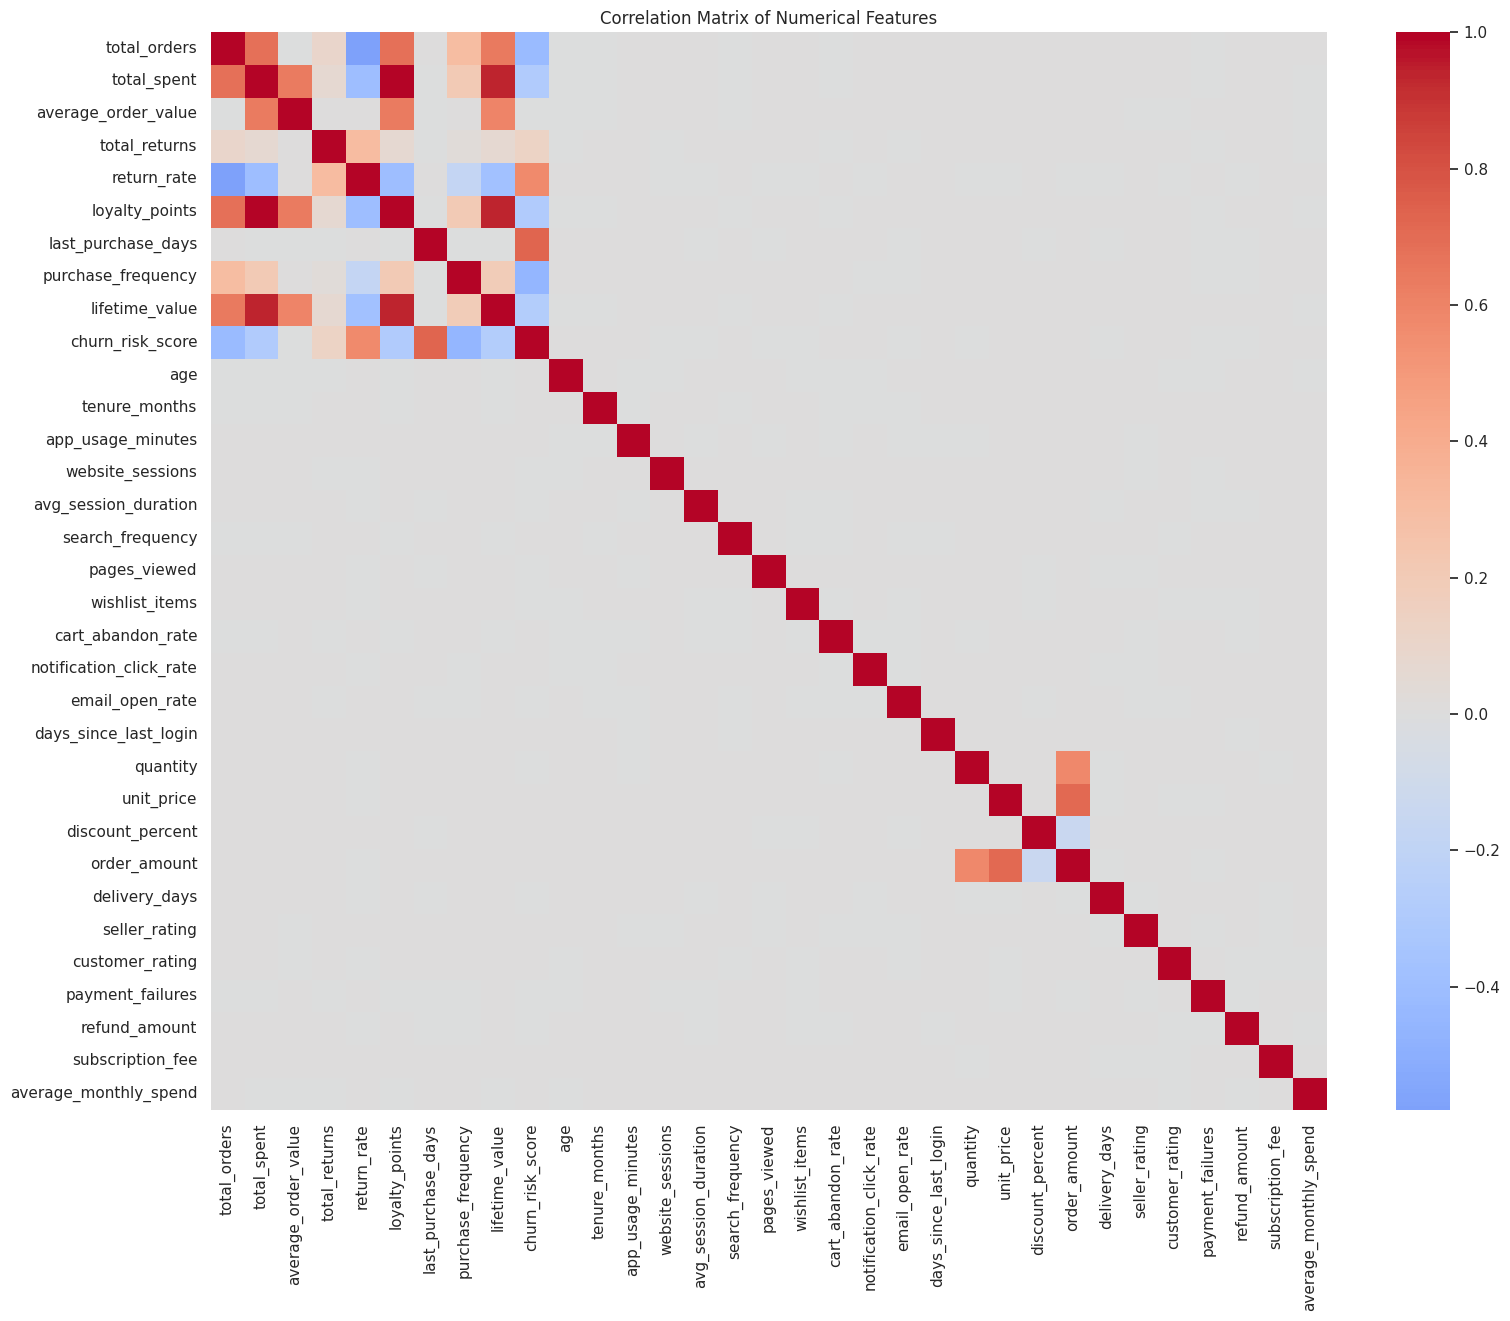

In [ ]:
corr_matrix = df_final[numeric_cols].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Numerical Features")
plt.savefig("/content/drive/MyDrive/Plots/Correlation Matrix of Numerical Features.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print(corr_pairs.head(20))

total_spent          loyalty_points         1.000000
loyalty_points       lifetime_value         0.943847
total_spent          lifetime_value         0.943847
last_purchase_days   churn_risk_score       0.725558
unit_price           order_amount           0.713685
total_orders         loyalty_points         0.682710
                     total_spent            0.682710
                     lifetime_value         0.644396
total_spent          average_order_value    0.633319
average_order_value  loyalty_points         0.633319
                     lifetime_value         0.597652
quantity             order_amount           0.585243
return_rate          churn_risk_score       0.568343
total_returns        return_rate            0.311953
total_orders         purchase_frequency     0.301731
total_spent          purchase_frequency     0.206997
loyalty_points       purchase_frequency     0.206997
purchase_frequency   lifetime_value         0.195267
total_returns        churn_risk_score       0.

In [ ]:
df_final["churn_binary"] = (
    df_final["churn"]
    .map({"No": 0, "Yes": 1})
)

churn_correlations = (
    df_final[numeric_cols.tolist() + ["churn_binary"]]
    .corr()["churn_binary"]
    .drop("churn_binary")
    .sort_values(ascending=False)
)

print(churn_correlations)

churn_risk_score           0.698751
last_purchase_days         0.511438
return_rate                0.495149
total_returns              0.126030
days_since_last_login      0.002682
tenure_months              0.002243
age                        0.001839
app_usage_minutes          0.001506
notification_click_rate    0.001147
payment_failures           0.000954
seller_rating              0.000365
average_monthly_spend      0.000235
discount_percent          -0.000028
pages_viewed              -0.000151
customer_rating           -0.000236
quantity                  -0.000500
avg_session_duration      -0.000660
email_open_rate           -0.000687
cart_abandon_rate         -0.000750
search_frequency          -0.001041
unit_price                -0.001132
order_amount              -0.001432
website_sessions          -0.001472
subscription_fee          -0.001591
average_order_value       -0.001634
wishlist_items            -0.001916
refund_amount             -0.002667
delivery_days             -0

In [ ]:
for col in categorical_cols:

    if col == "churn":
        continue

    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    result = (
        df_final
        .assign(churn_binary=df_final["churn"].eq("Yes"))
        .groupby(col)["churn_binary"]
        .agg(["count", "mean"])
    )

    result["churn_rate_%"] = result["mean"] * 100

    print(
        result
        .drop(columns="mean")
        .sort_values("churn_rate_%", ascending=False)
        .head(20)
    )


customer_segment
                   count  churn_rate_%
customer_segment                      
At Risk           178566     66.953955
New                51479     47.436819
High Value        299572      9.832027
Loyal             131827      8.612803
Occasional        338556      6.624606

gender
         count  churn_rate_%
gender                      
Other    19826     20.760617
Male    491421     20.726017
Female  488753     20.714962

city
            count  churn_rate_%
city                           
Mumbai     125008     20.981057
Chennai    125756     20.888069
Delhi      124795     20.842982
Ahmedabad  125781     20.820315
Faridabad  125181     20.779511
Kolkata    124155     20.666908
Bengaluru  124315     20.416683
Hyderabad  125009     20.371333

state
              count  churn_rate_%
state                            
Gujarat      124527     20.931204
Telangana    125496     20.892299
Haryana      124937     20.890529
Maharashtra  124665     20.726748
Delhi        123857

['customer_segment', 'gender', 'city', 'state', 'country', 'membership_tier', 'occupation', 'income_group', 'marital_status', 'education', 'preferred_device', 'referral_source', 'product_category', 'payment_method_x', 'coupon_used', 'order_status', 'returned', 'return_reason', 'payment_method_y', 'payment_status', 'subscription_active']


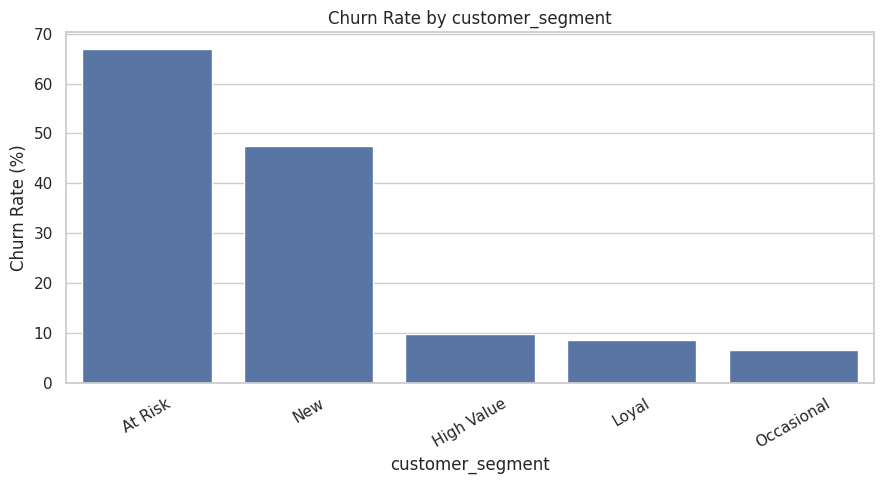

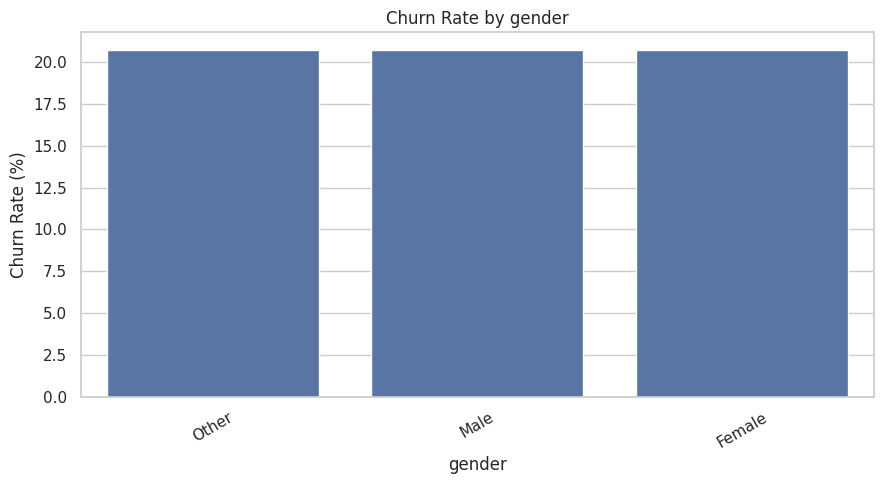

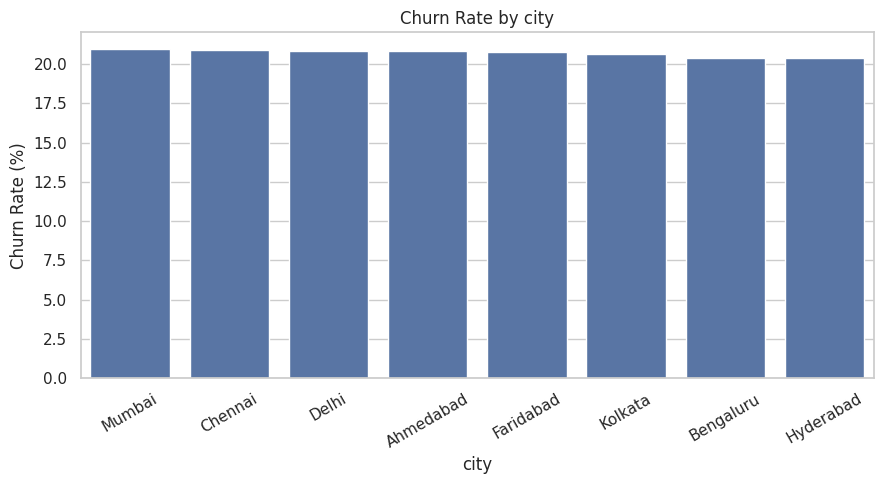

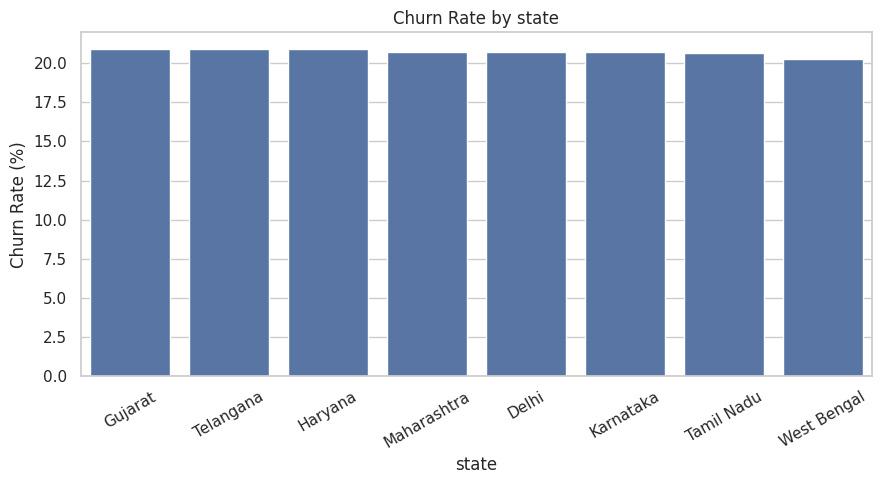

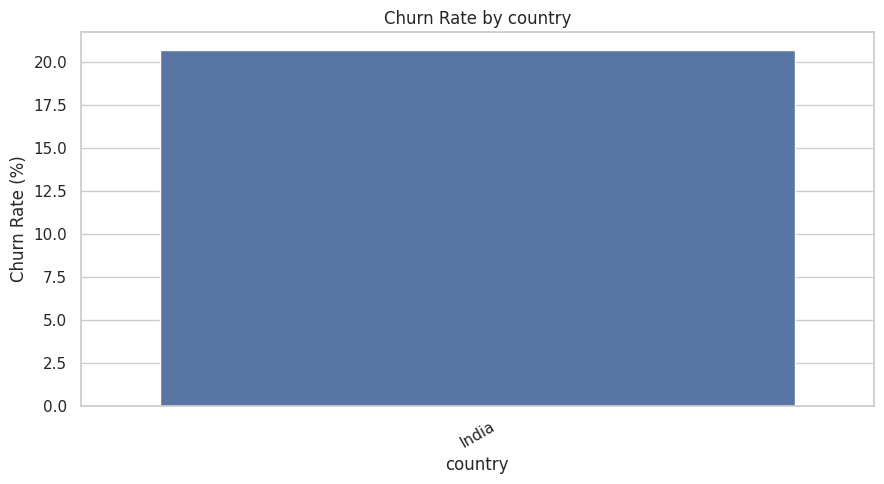

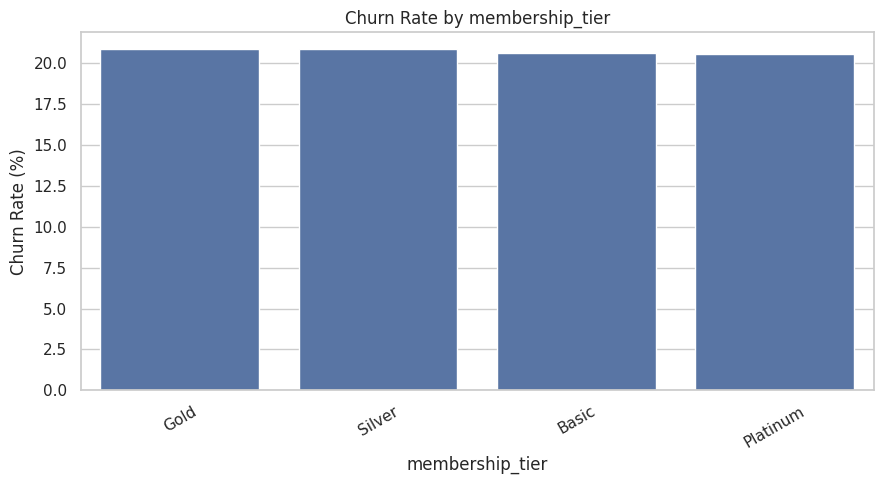

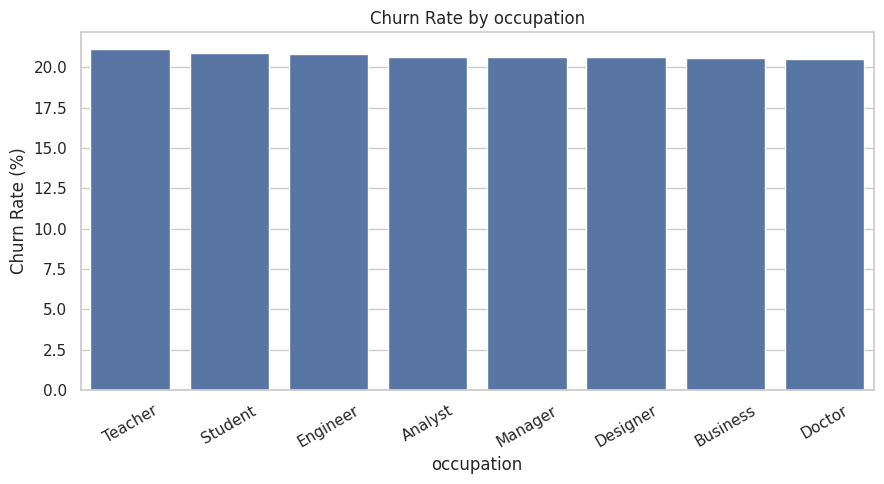

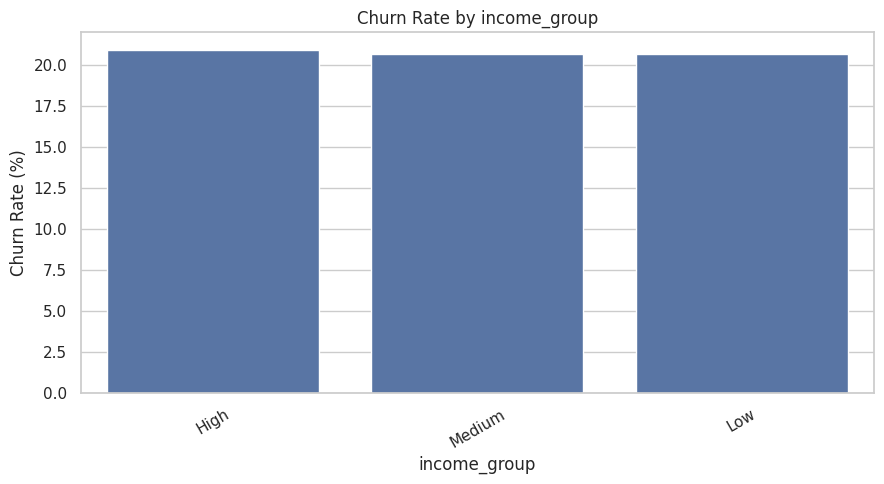

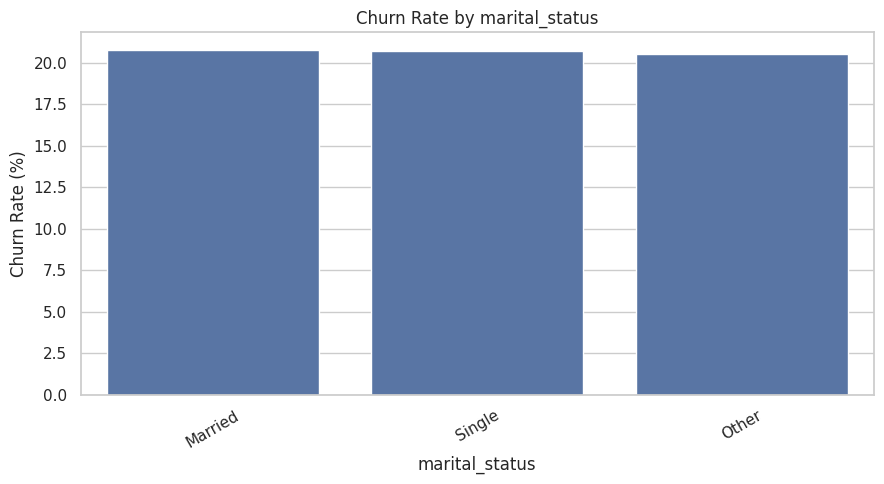

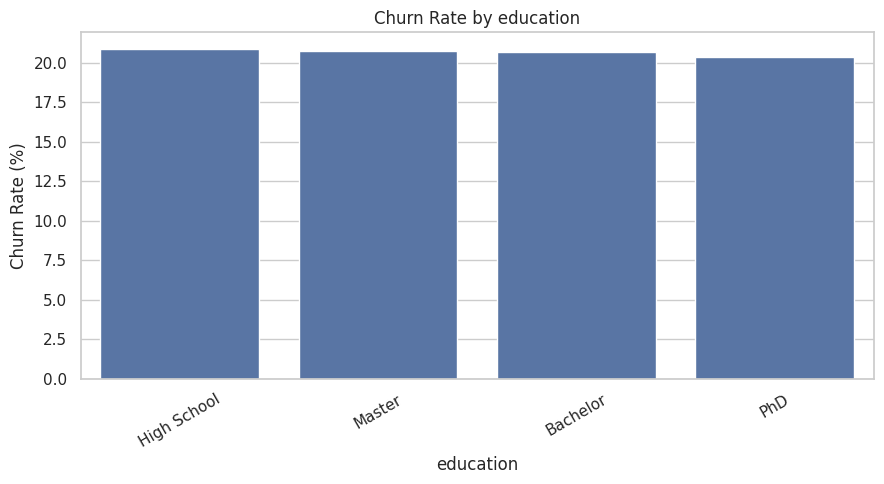

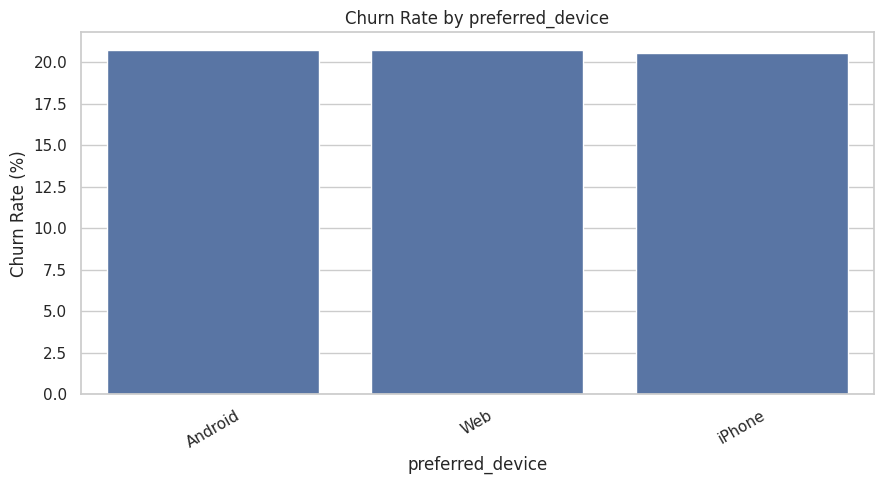

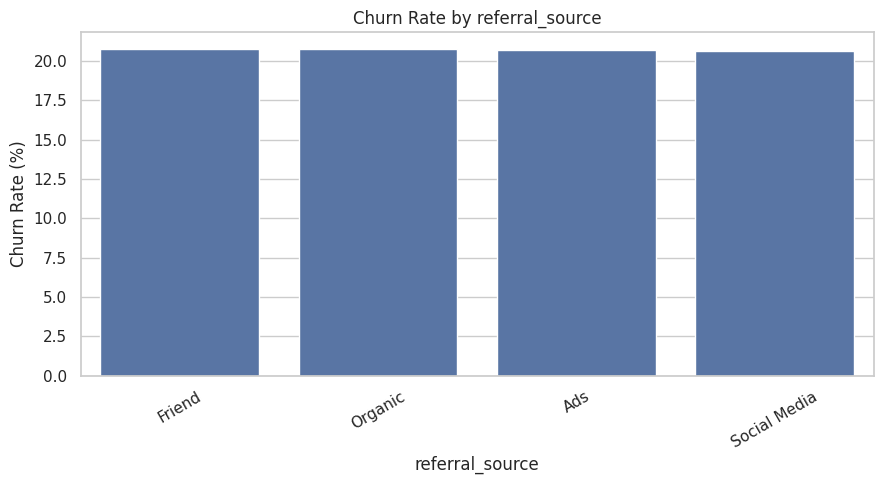

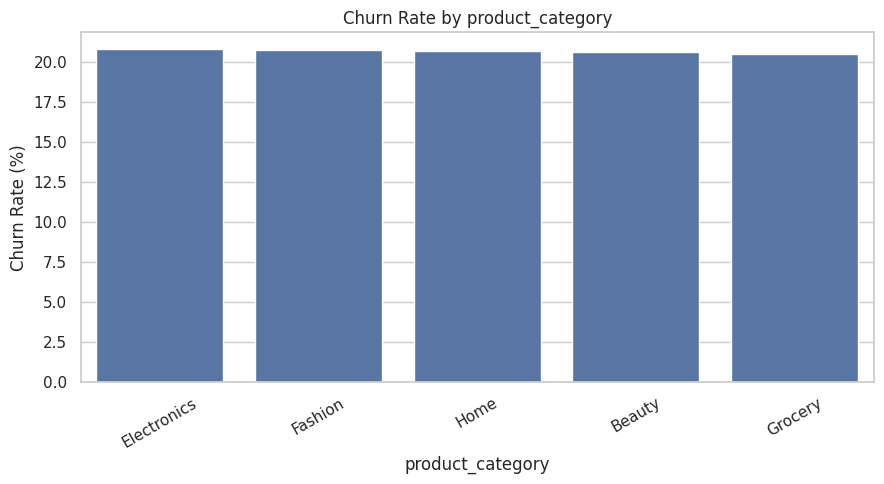

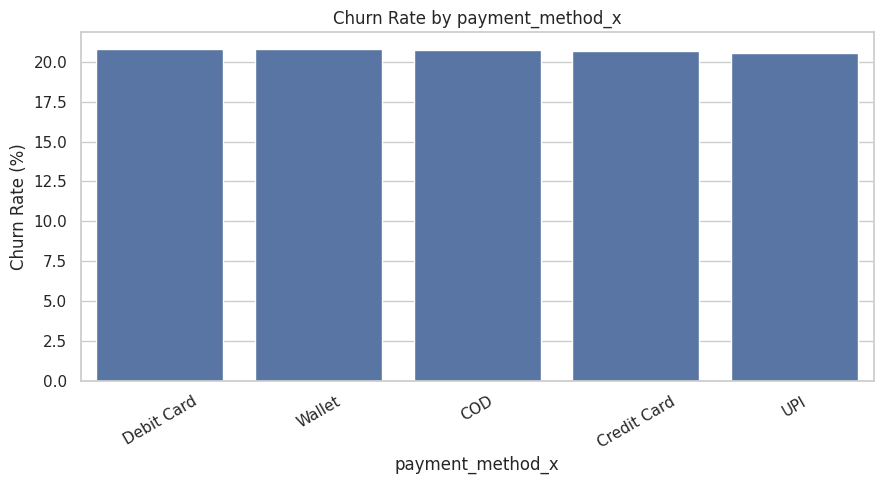

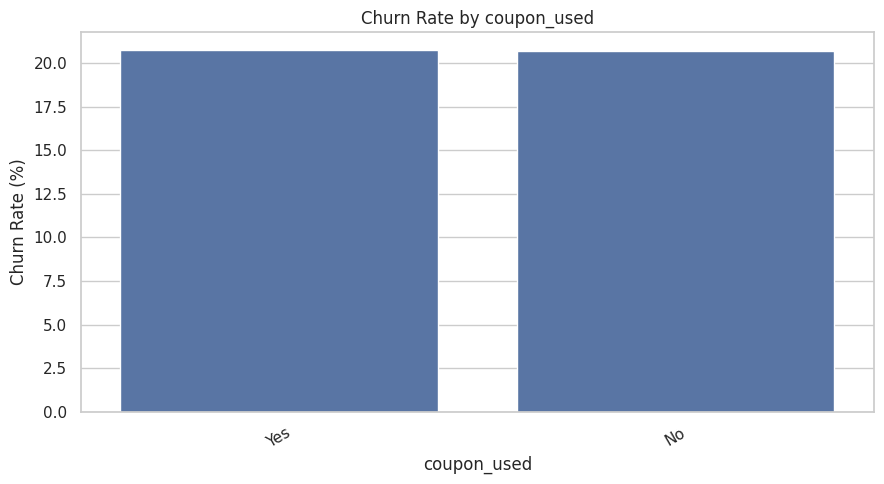

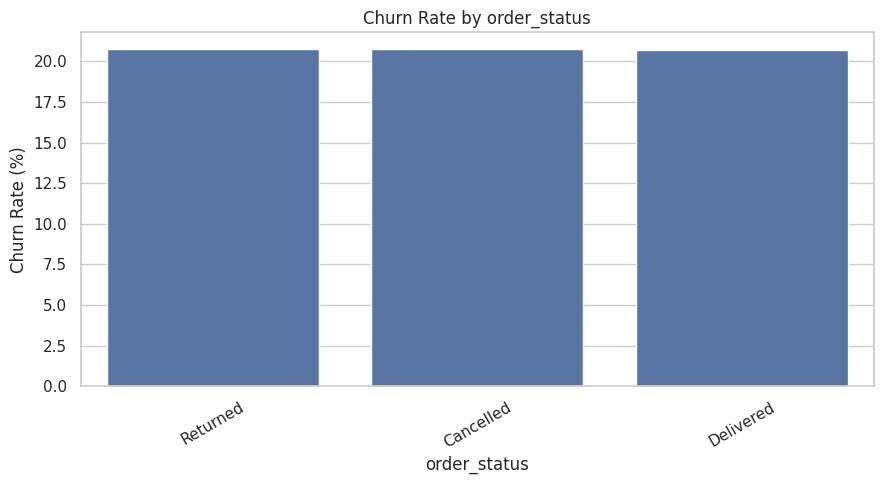

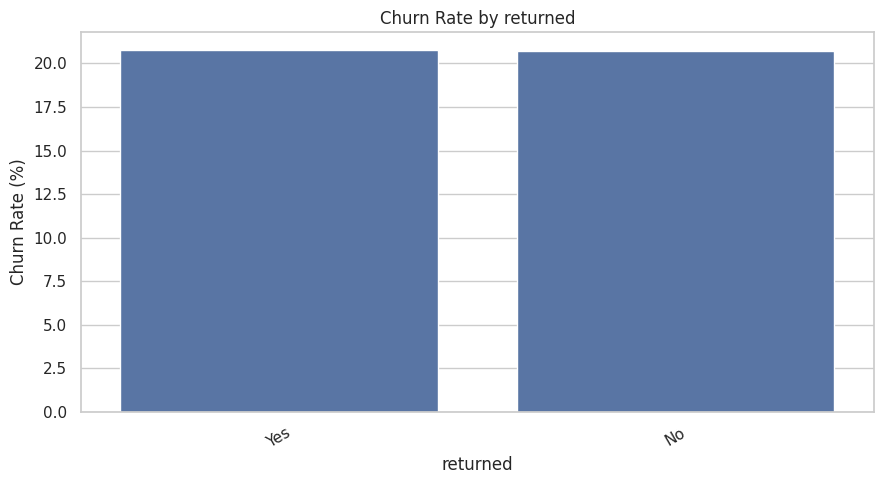

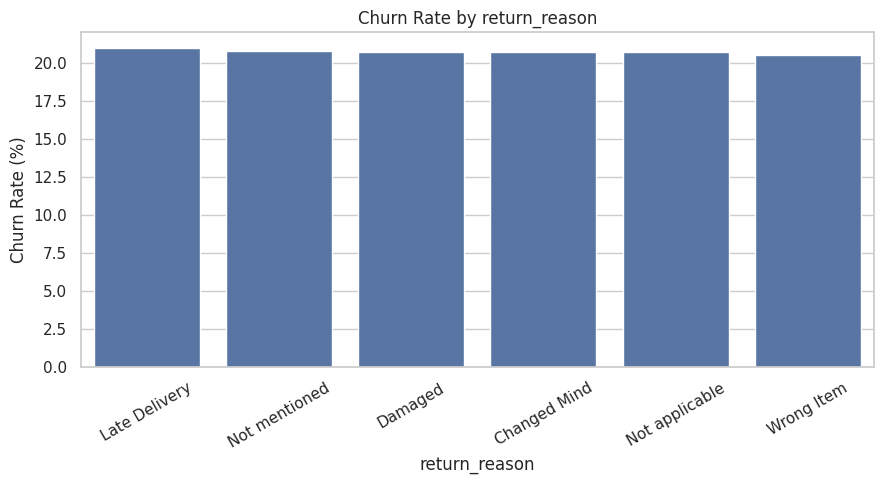

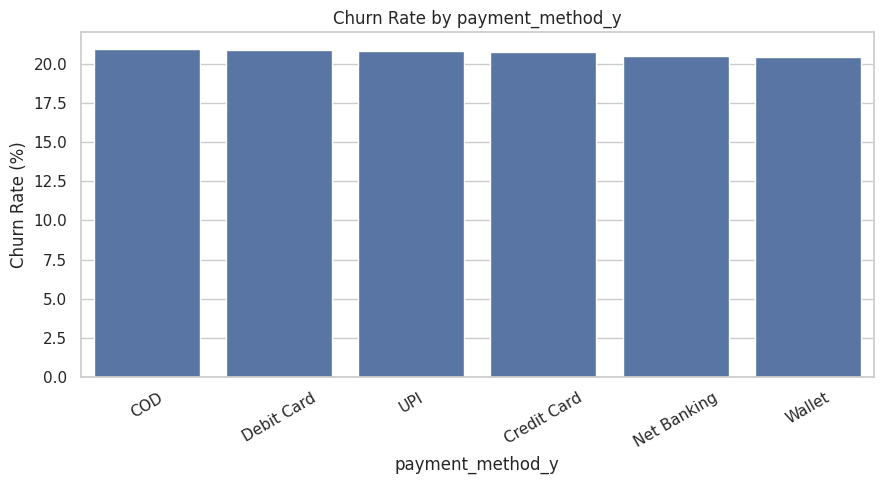

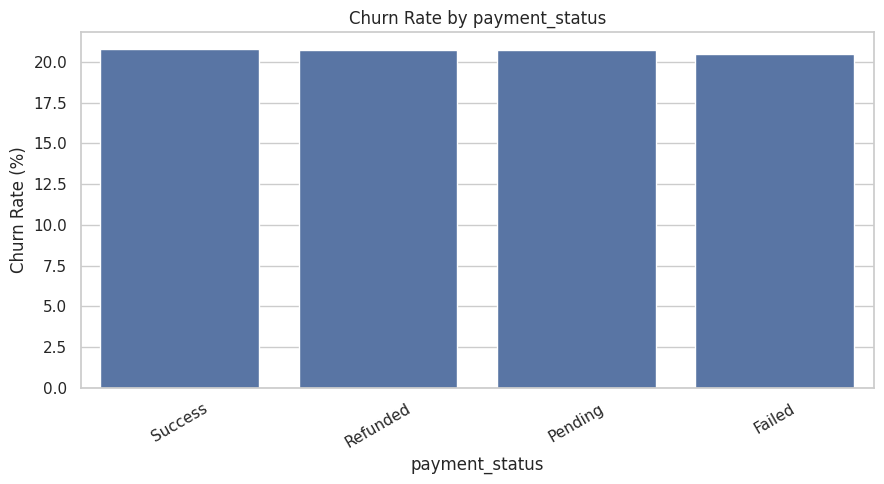

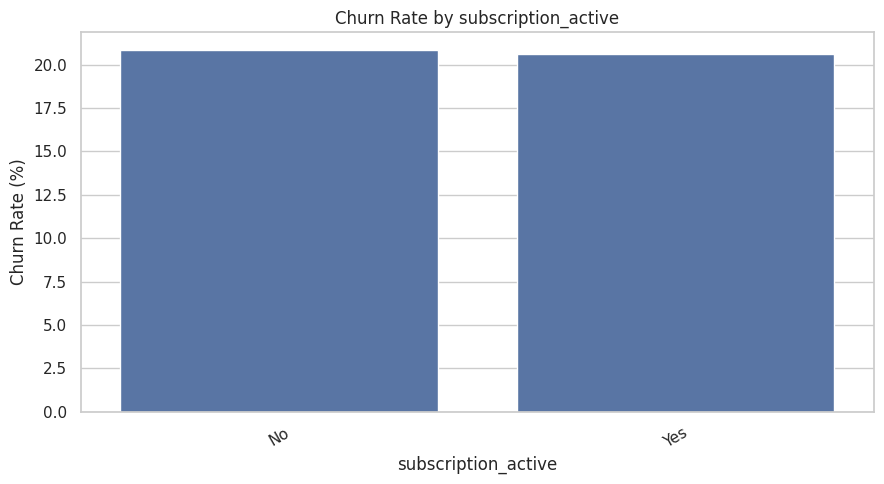

In [ ]:
low_cardinality_cols = [
    col for col in categorical_cols
    if df_final[col].nunique() <= 10
    and col != "churn"
]

print(low_cardinality_cols)

for col in low_cardinality_cols:

    churn_rate = (
        df_final
        .assign(churn_binary=df_final["churn"].eq("Yes"))
        .groupby(col)["churn_binary"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values
    )

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/Plots/Customer_Churn_By_{col}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

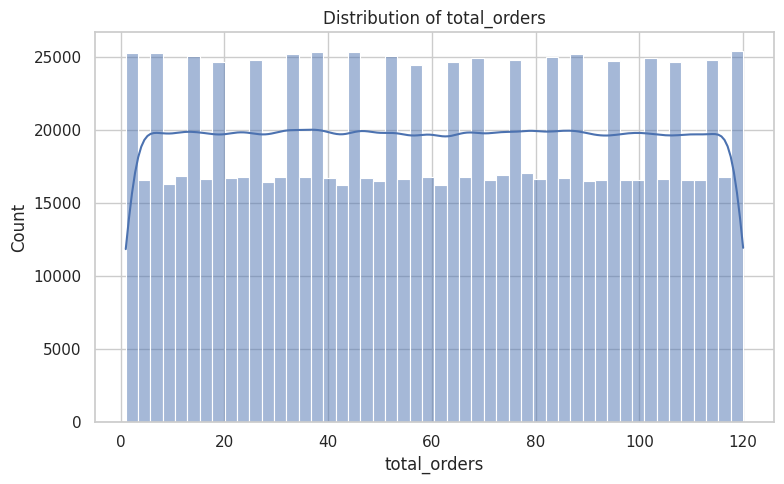

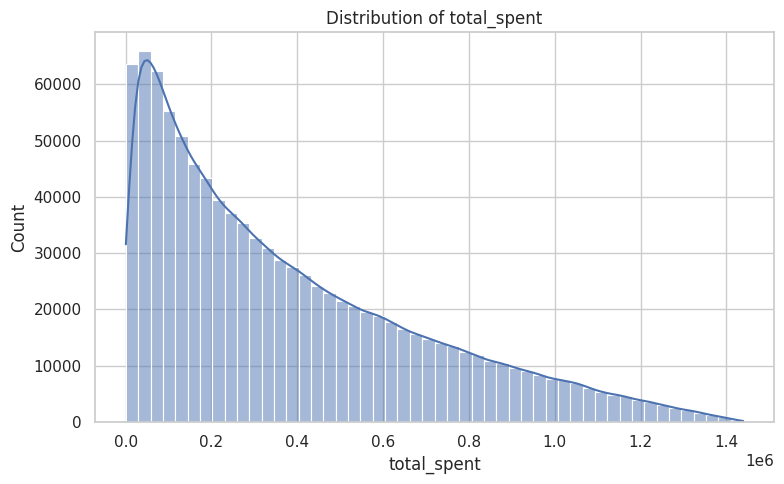

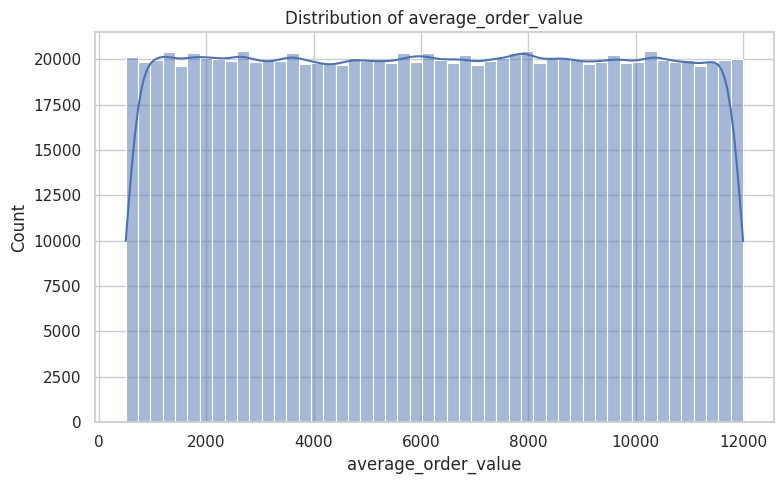

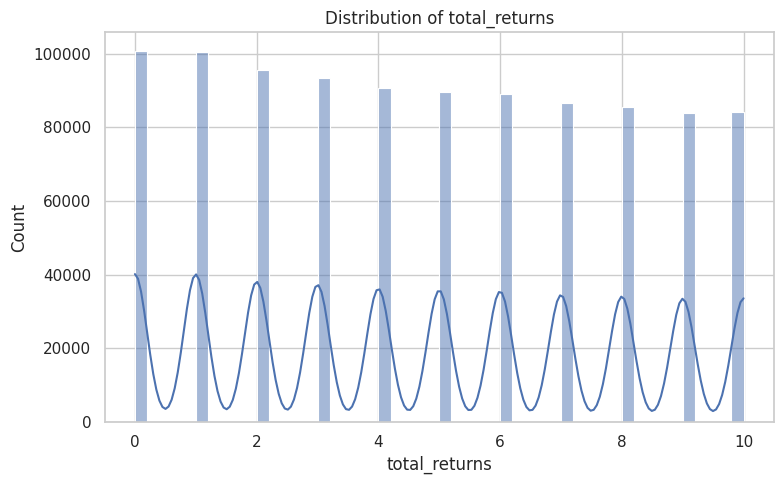

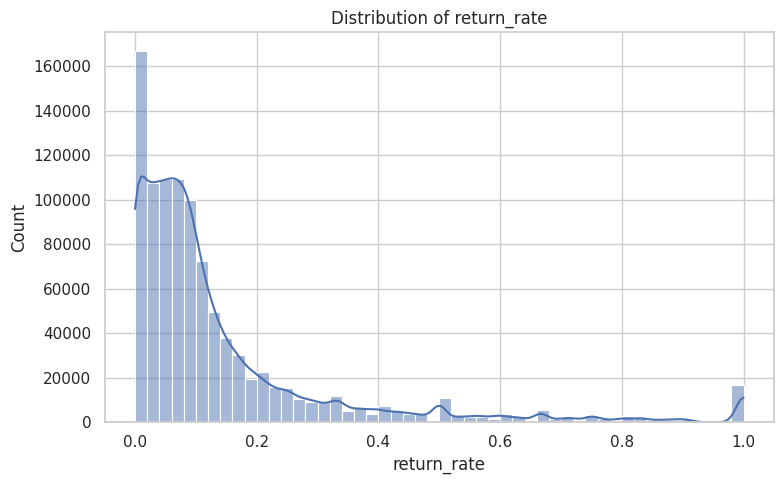

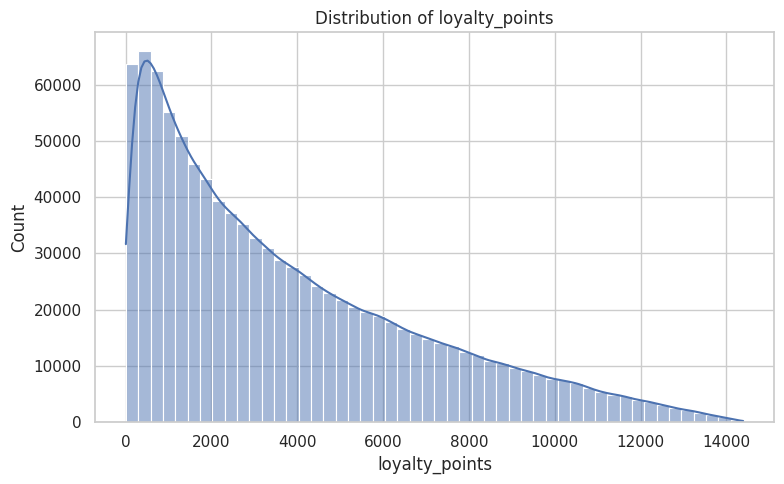

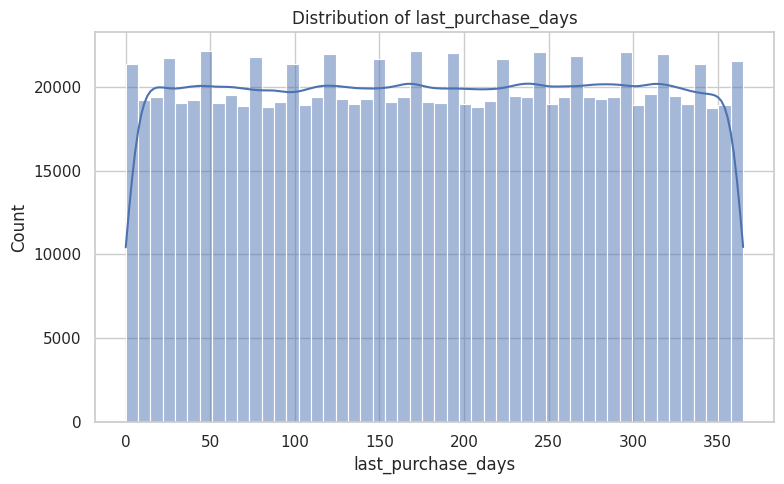

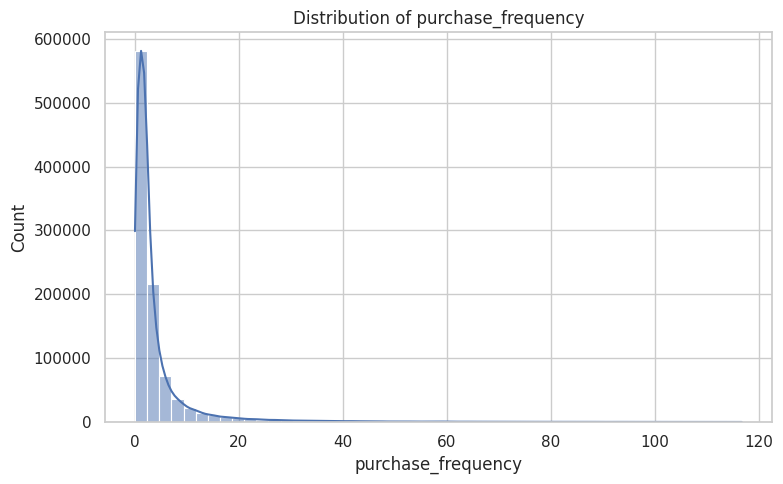

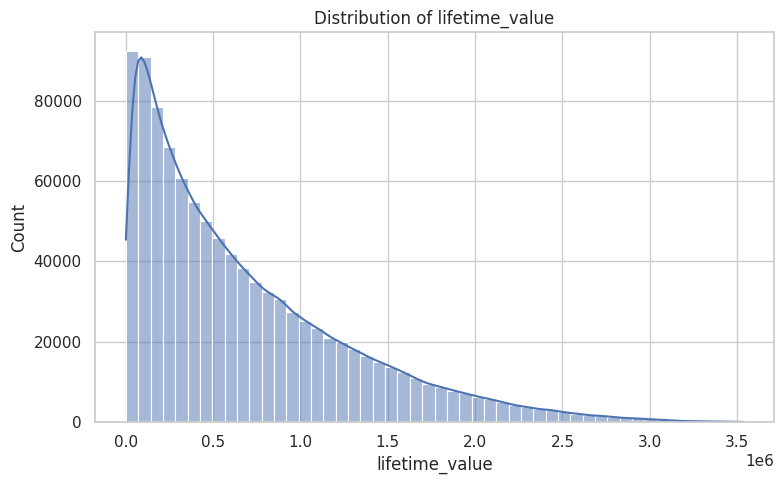

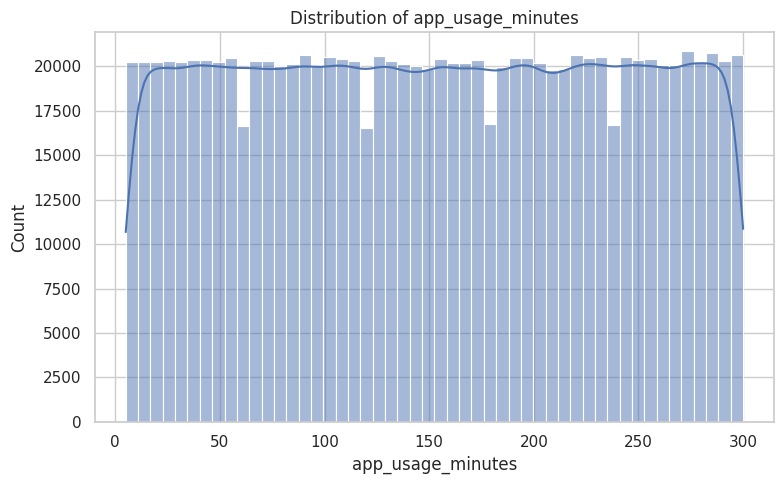

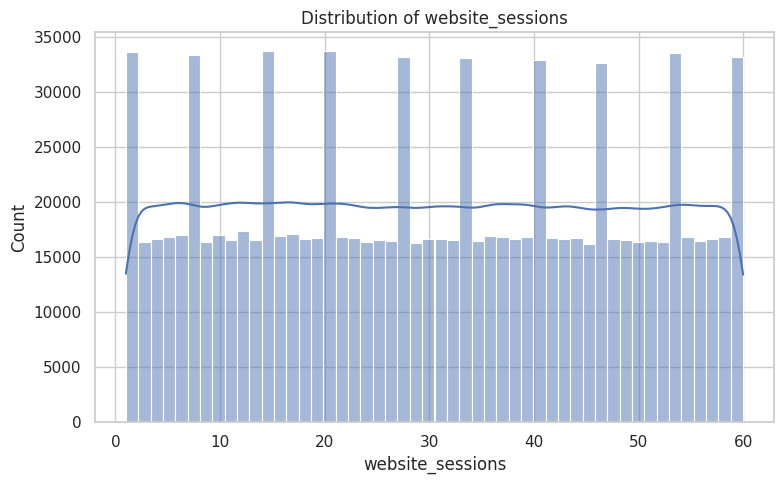

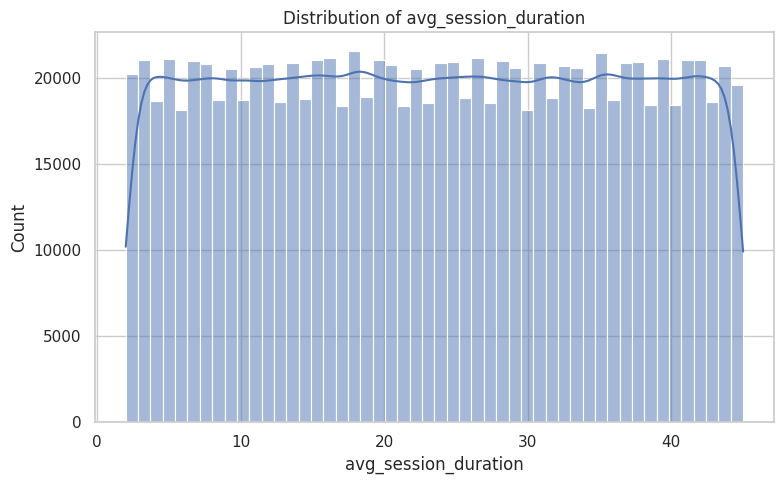

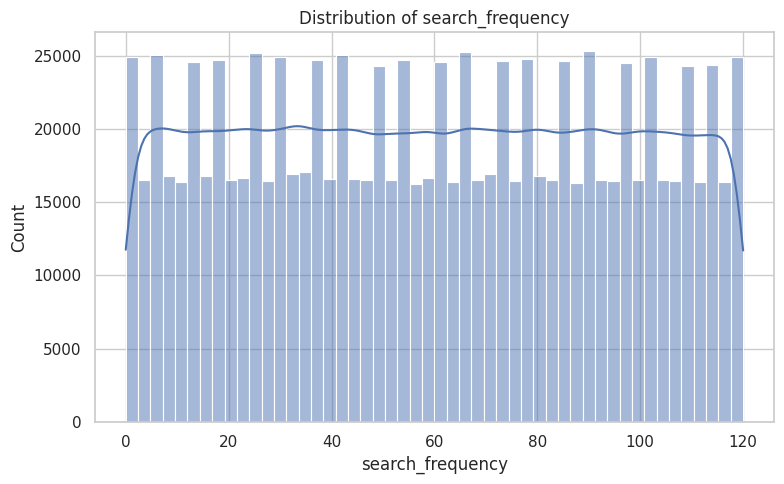

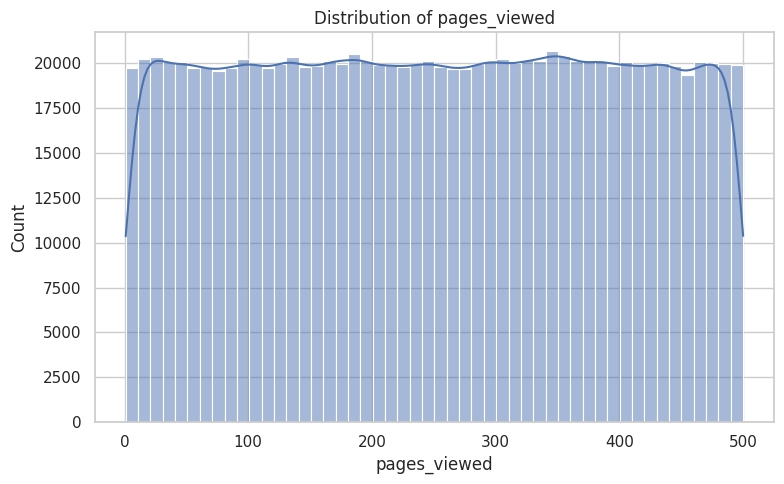

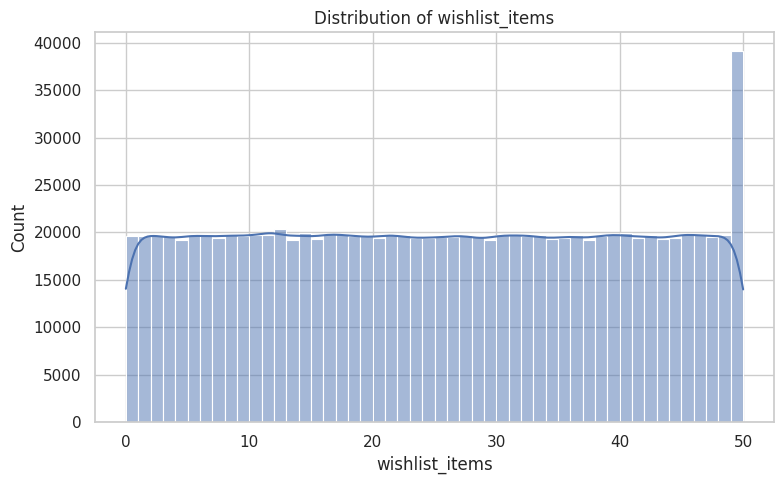

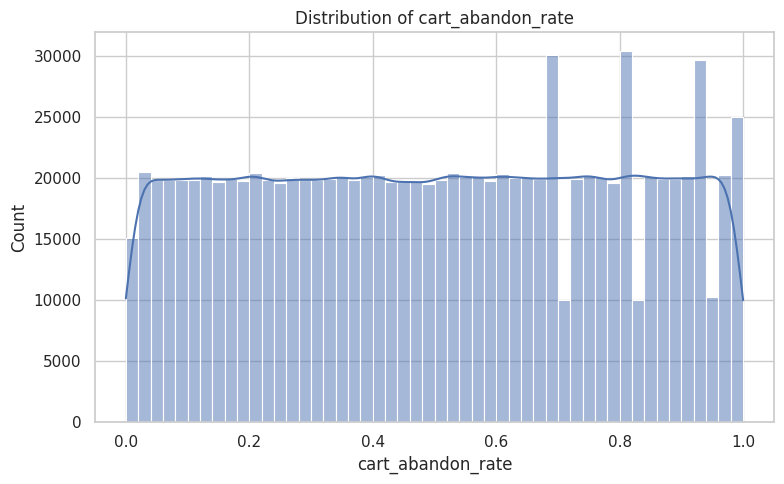

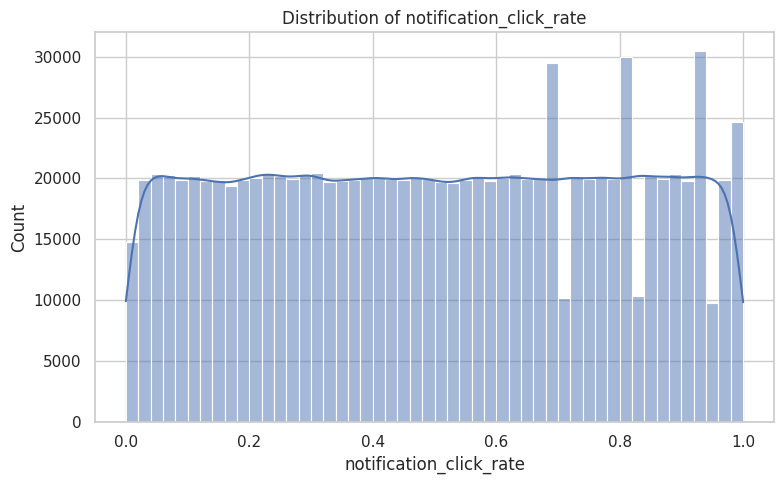

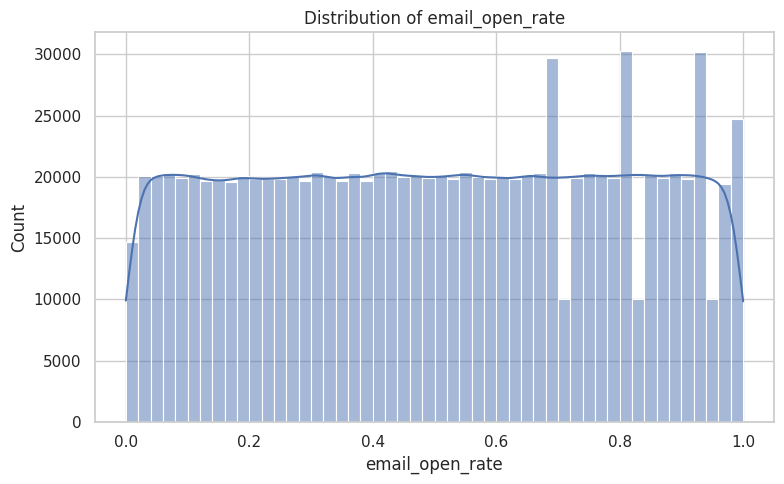

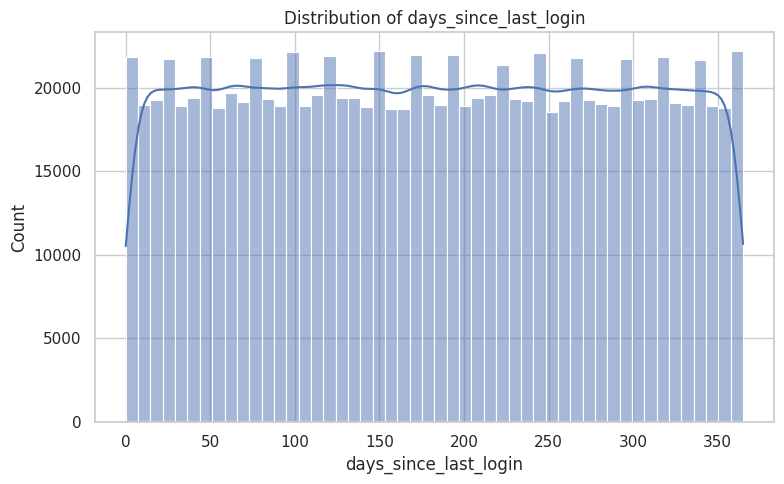

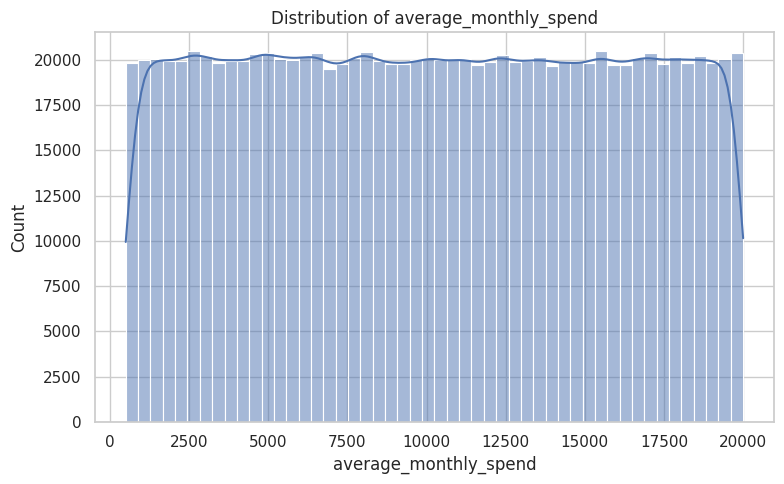

In [ ]:
important_numeric = [
    "total_orders",
    "total_spent",
    "average_order_value",
    "total_returns",
    "return_rate",
    "loyalty_points",
    "last_purchase_days",
    "purchase_frequency",
    "lifetime_value",
    "app_usage_minutes",
    "website_sessions",
    "avg_session_duration",
    "search_frequency",
    "pages_viewed",
    "wishlist_items",
    "cart_abandon_rate",
    "notification_click_rate",
    "email_open_rate",
    "days_since_last_login",
    "average_monthly_spend"
]

for col in important_numeric:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df_final,
        x=col,
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/Plots/Distribution_of_{col}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

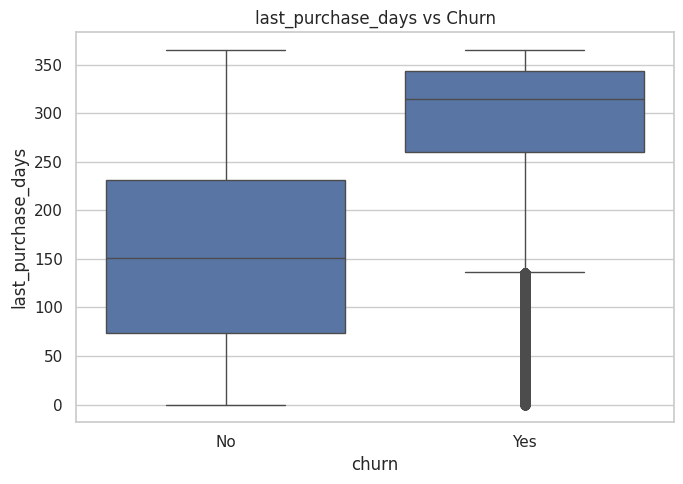

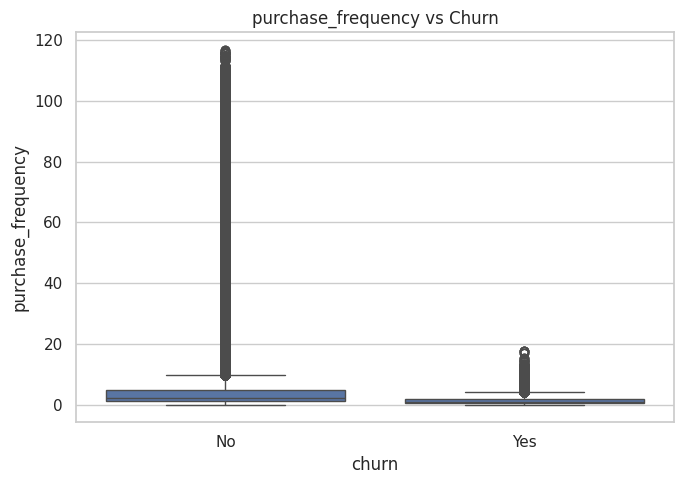

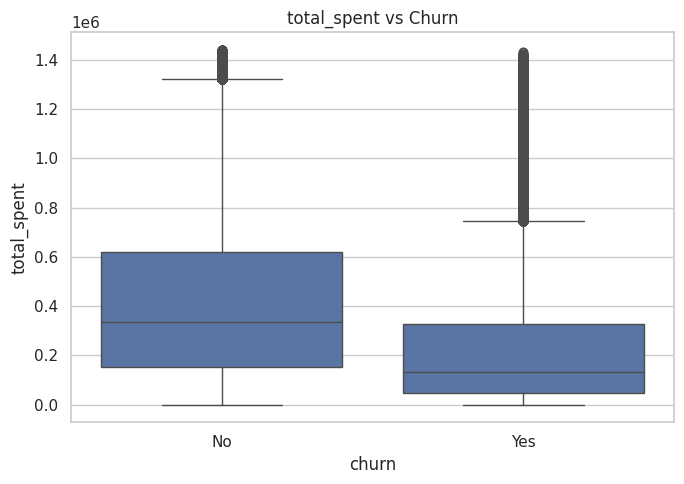

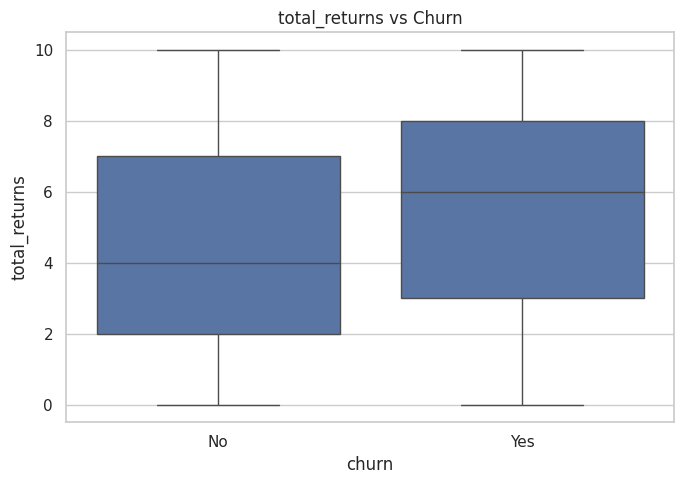

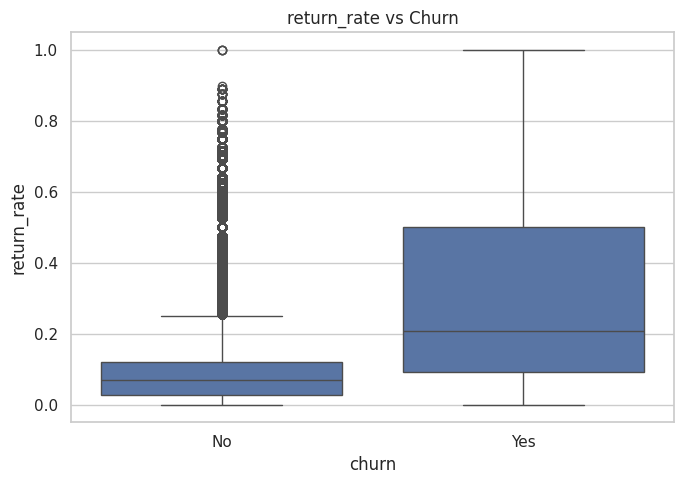

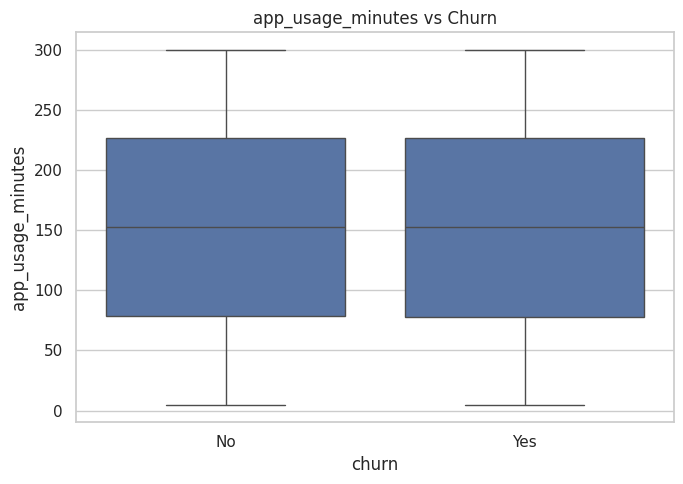

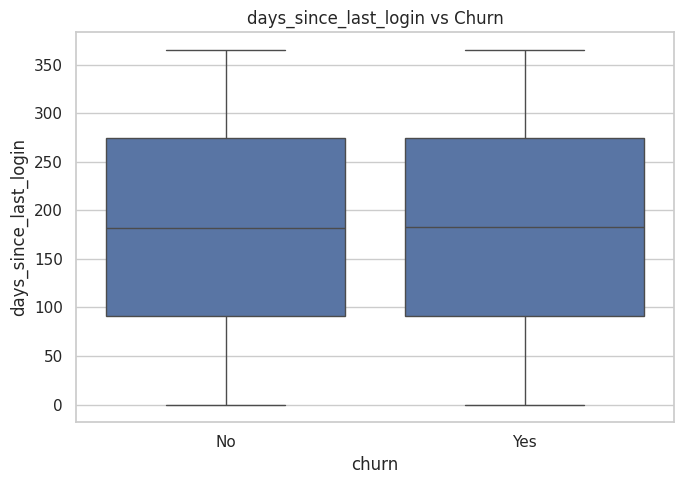

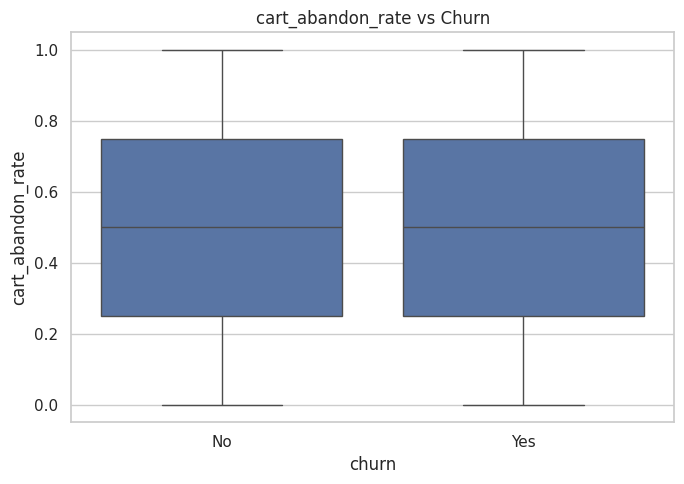

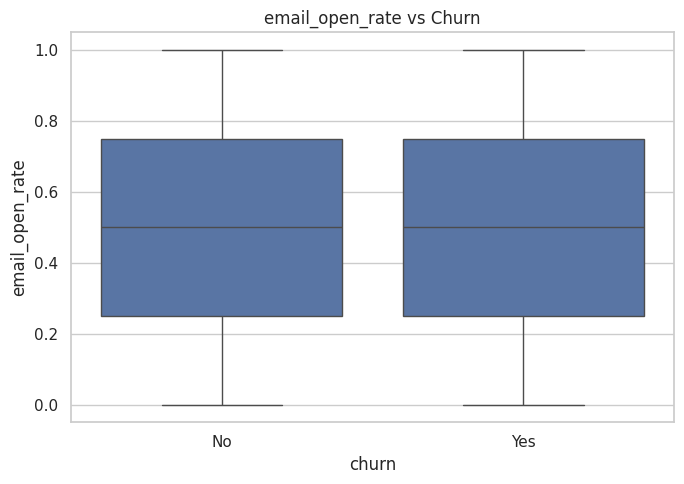

In [ ]:
features_to_plot = [
    "last_purchase_days",
    "purchase_frequency",
    "total_spent",
    "total_returns",
    "return_rate",
    "app_usage_minutes",
    "days_since_last_login",
    "cart_abandon_rate",
    "email_open_rate"
]

for col in features_to_plot:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=df_final,
        x="churn",
        y=col
    )
    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()

In [ ]:
for col in numeric_cols:

    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (df_final[col] < lower) |
        (df_final[col] > upper)
    ).sum()

    print(
        f"{col}: {outliers:,} outliers "
        f"({outliers / len(df_final) * 100:.2f}%)"
    )

total_orders: 0 outliers (0.00%)
total_spent: 10,405 outliers (1.04%)
average_order_value: 0 outliers (0.00%)
total_returns: 0 outliers (0.00%)
return_rate: 103,355 outliers (10.34%)
loyalty_points: 10,391 outliers (1.04%)
last_purchase_days: 0 outliers (0.00%)
purchase_frequency: 109,965 outliers (11.00%)
lifetime_value: 26,770 outliers (2.68%)
churn_risk_score: 13,354 outliers (1.34%)
age: 0 outliers (0.00%)
tenure_months: 0 outliers (0.00%)
app_usage_minutes: 0 outliers (0.00%)
website_sessions: 0 outliers (0.00%)
avg_session_duration: 0 outliers (0.00%)
search_frequency: 0 outliers (0.00%)
pages_viewed: 0 outliers (0.00%)
wishlist_items: 0 outliers (0.00%)
cart_abandon_rate: 0 outliers (0.00%)
notification_click_rate: 0 outliers (0.00%)
email_open_rate: 0 outliers (0.00%)
days_since_last_login: 0 outliers (0.00%)
quantity: 0 outliers (0.00%)
unit_price: 0 outliers (0.00%)
discount_percent: 0 outliers (0.00%)
order_amount: 14,857 outliers (1.49%)
delivery_days: 0 outliers (0.00%)
se

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_final.sample(10000, random_state=42),
    x="total_spent",
    y="lifetime_value",
    hue="churn",
    alpha=0.5
)

plt.title("Total Spent vs Lifetime Value")
plt.savefig("/content/drive/MyDrive/Plots/Total Spent vs Lifetime Value.png", dpi=300, bbox_inches="tight")
plt.show()

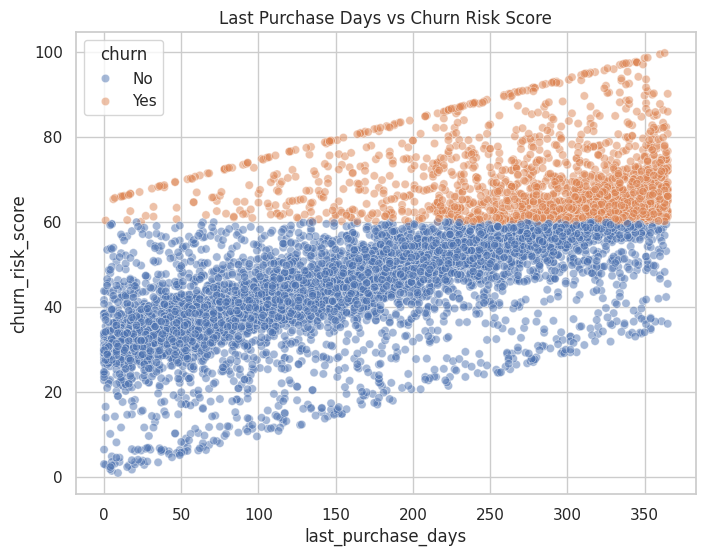

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_final.sample(10000, random_state=42),
    x="last_purchase_days",
    y="churn_risk_score",
    hue="churn",
    alpha=0.5
)

plt.title("Last Purchase Days vs Churn Risk Score")
plt.savefig("/content/drive/MyDrive/Plots/Last Purchase Days vs Churn Risk Score.png", dpi=300, bbox_inches="tight")
plt.show()

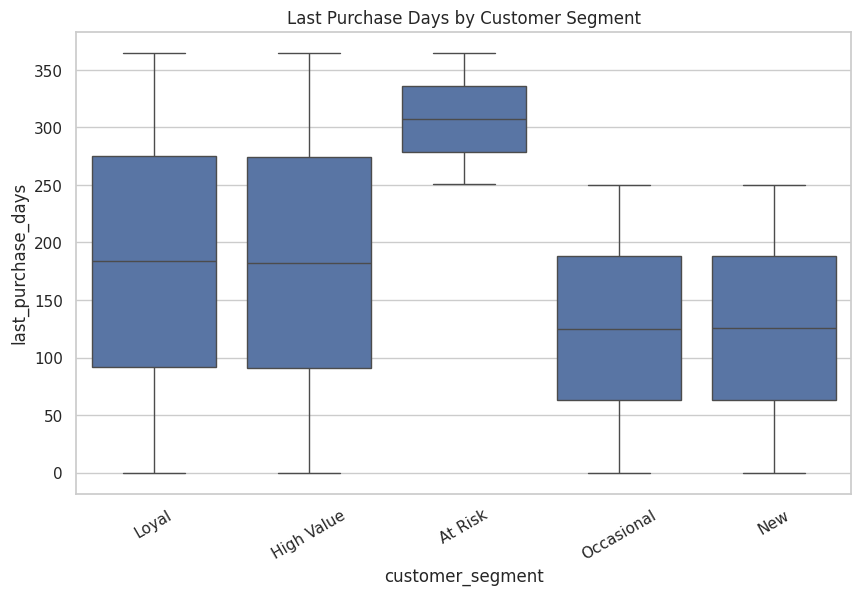

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_final,
    x="customer_segment",
    y="last_purchase_days"
)

plt.title("Last Purchase Days by Customer Segment")
plt.xticks(rotation=30)

plt.savefig("/content/drive/MyDrive/Plots/Last Purchase Days by Customer Segment.png", dpi=300, bbox_inches="tight")
plt.show()

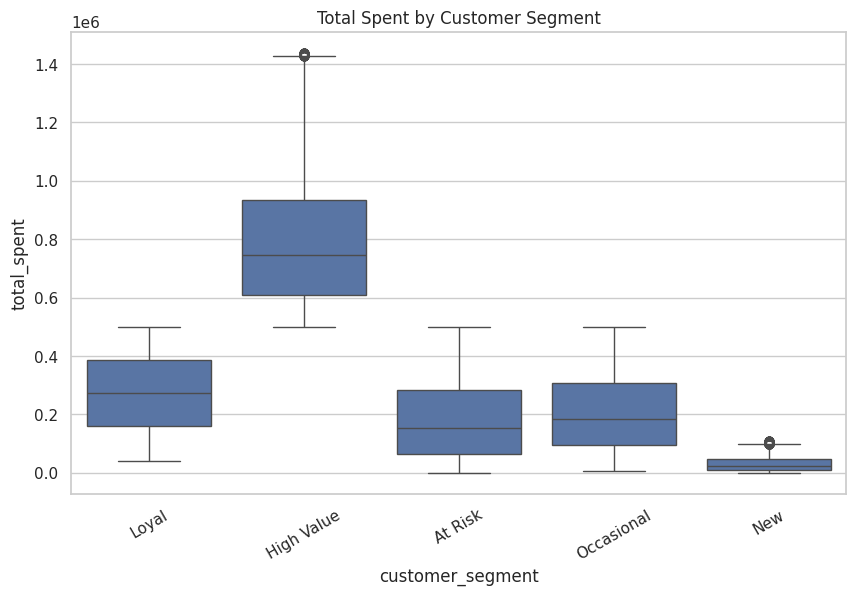

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_final,
    x="customer_segment",
    y="total_spent"
)

plt.title("Total Spent by Customer Segment")
plt.xticks(rotation=30)

plt.savefig("/content/drive/MyDrive/Plots/Total Spent by Customer Segment.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df_final.drop(columns=["churn_binary"], inplace=True)